In [1]:
# ============================================================
# STAGE 2 — FEATURE ABLATION (IN-MEMORY + PLOTS SHOWN)
# Student-Independent Sign Language Recognition
# 120 Frames × Configurable Feature Subset
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Bidirectional,
    Attention,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# 1. SETTINGS
# ============================================================

BASE_DIR = r"D:\aaa EAAI Major Revision\dynamic\dynamic_dataset"
DATA_DIR = os.path.join(BASE_DIR, "csv_dataset")

TRAIN_PATH = os.path.join(DATA_DIR, "train_csv")
VAL_PATH = os.path.join(DATA_DIR, "validation_csv")
TEST_PATH = os.path.join(DATA_DIR, "test_csv")

ORIGINAL_SEQUENCE_LENGTH = 120
TARGET_FRAMES = 120
EXPECTED_CLASSES = 40

only hands, exclude elbow and wrist


FEATURE ABLATION CONFIGURATION
Experiment: 126F_left_hand_right_hand
Target frames: 120
Left hand: True
Right hand: True
Wrist distances: False
Elbow distances: False
Selected feature indices (0-based): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125]
Number of selected features: 126

CHECKING DATASET
Train path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\train_csv
Validation path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\validation_csv
Test path: D:\aaa EAAI Major Revision\dynami

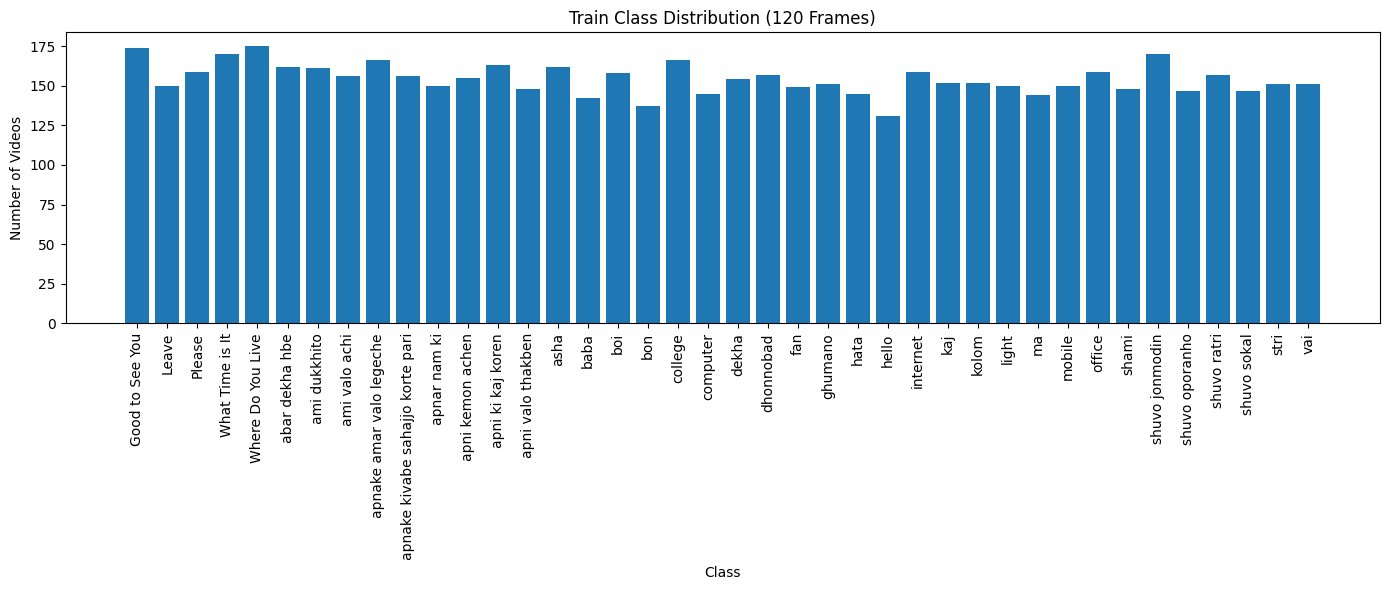


--- VALIDATION Class Distribution ---
Good to See You: 27 videos
Leave: 35 videos
Please: 29 videos
What Time is It: 28 videos
Where Do You Live: 38 videos
abar dekha hbe: 31 videos
ami dukkhito: 31 videos
ami valo achi: 28 videos
apnake amar valo legeche: 29 videos
apnake kivabe sahajjo korte pari: 31 videos
apnar nam ki: 32 videos
apni kemon achen: 35 videos
apni ki kaj koren: 33 videos
apni valo thakben: 33 videos
asha: 34 videos
baba: 30 videos
boi: 33 videos
bon: 31 videos
college: 31 videos
computer: 37 videos
dekha: 33 videos
dhonnobad: 27 videos
fan: 32 videos
ghumano: 31 videos
hata: 30 videos
hello: 30 videos
internet: 34 videos
kaj: 29 videos
kolom: 37 videos
light: 41 videos
ma: 31 videos
mobile: 29 videos
office: 31 videos
shami: 30 videos
shuvo jonmodin: 34 videos
shuvo oporanho: 30 videos
shuvo ratri: 34 videos
shuvo sokal: 38 videos
stri: 29 videos
vai: 29 videos


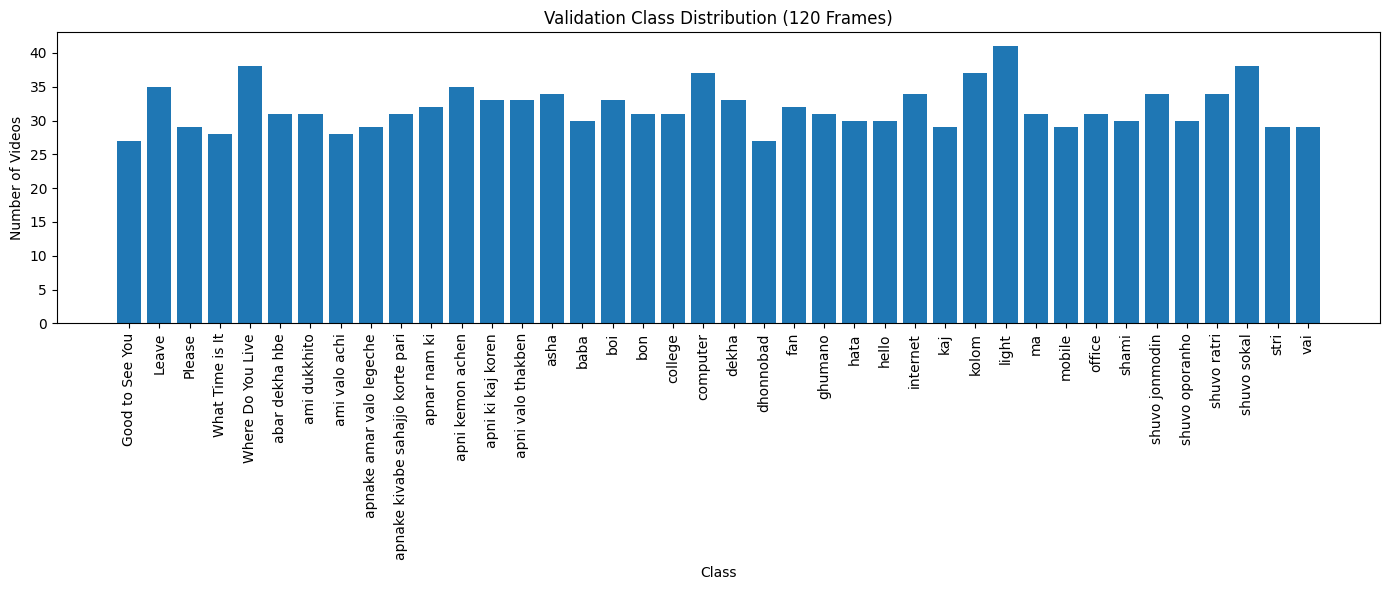


--- TEST Class Distribution ---
Good to See You: 33 videos
Leave: 28 videos
Please: 32 videos
What Time is It: 31 videos
Where Do You Live: 31 videos
abar dekha hbe: 38 videos
ami dukkhito: 30 videos
ami valo achi: 28 videos
apnake amar valo legeche: 31 videos
apnake kivabe sahajjo korte pari: 30 videos
apnar nam ki: 31 videos
apni kemon achen: 32 videos
apni ki kaj koren: 30 videos
apni valo thakben: 31 videos
asha: 29 videos
baba: 32 videos
boi: 28 videos
bon: 31 videos
college: 34 videos
computer: 33 videos
dekha: 28 videos
dhonnobad: 29 videos
fan: 32 videos
ghumano: 29 videos
hata: 28 videos
hello: 29 videos
internet: 30 videos
kaj: 31 videos
kolom: 29 videos
light: 27 videos
ma: 29 videos
mobile: 32 videos
office: 29 videos
shami: 28 videos
shuvo jonmodin: 30 videos
shuvo oporanho: 30 videos
shuvo ratri: 33 videos
shuvo sokal: 29 videos
stri: 29 videos
vai: 28 videos


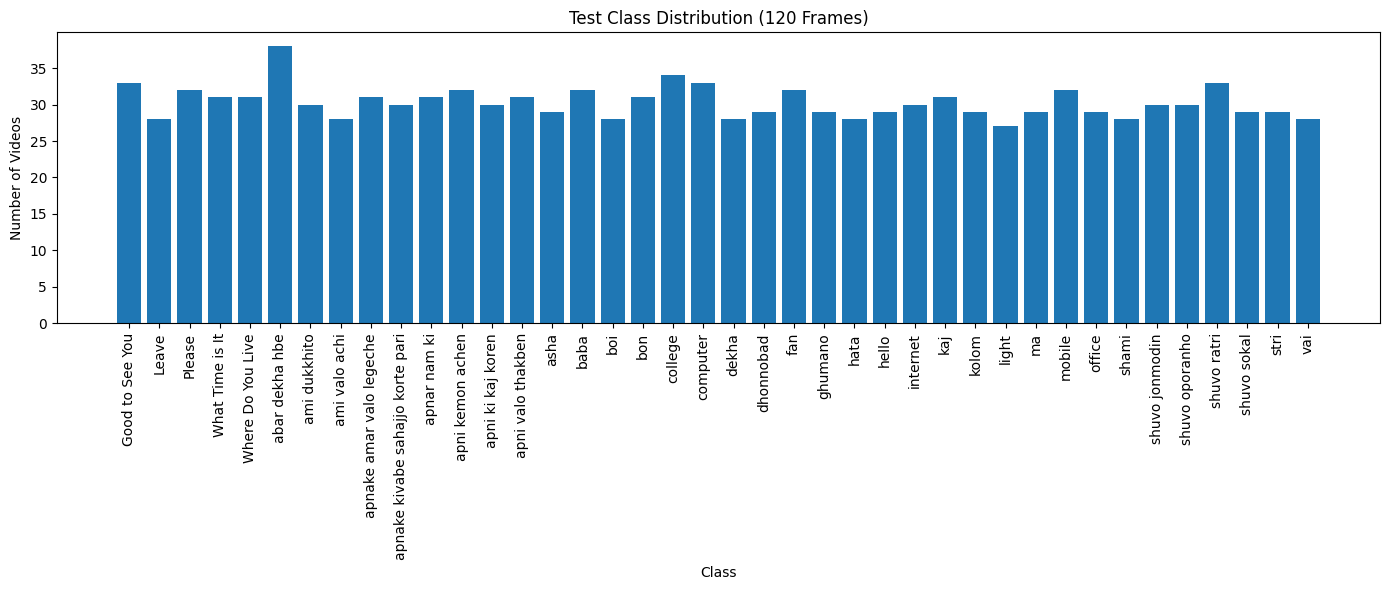


STANDARDIZATION
Fitting scaler on training data...
Transforming validation data...
Transforming test data...
Scaling completed.

BUILDING MODEL


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 126)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 120, 64)   │     24,256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 120, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 120, 256)  │    197,632 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 256)  │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 120, 256)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 120, 128)  │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 128)  │        512 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 120, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 120, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 120, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 120, 64)   │          0 │ dense[0][0],      │
│ (Attention)         │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 40)        │      2,600 │ dropout_3[0][0] 

 Total params: 424,488 (1.62 MB)

 Trainable params: 423,208 (1.61 MB)

 Non-trainable params: 1,280 (5.00 KB)


TRAINING
Epoch 1/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0539 - loss: 4.0042
[Epoch 1] Validation accuracy improved to 0.2110. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.0798 - loss: 3.6731 - val_accuracy: 0.2110 - val_loss: 3.1555 - learning_rate: 5.0000e-04
Epoch 2/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1970 - loss: 2.9145
[Epoch 2] Validation accuracy improved to 0.4525. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.2196 - loss: 2.7660 - val_accuracy: 0.4525 - val_loss: 2.2603 - learning_rate: 5.0000e-04
Epoch 3/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3151 - loss: 2.3572
[Epoch 3] Validation accuracy improved to 0.5898. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.3342 - loss: 2.2465 - val_accuracy: 0.5898 - val_loss: 1.5213 - learning_rate: 5.0000e-04
Epoch 4/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4268 - l

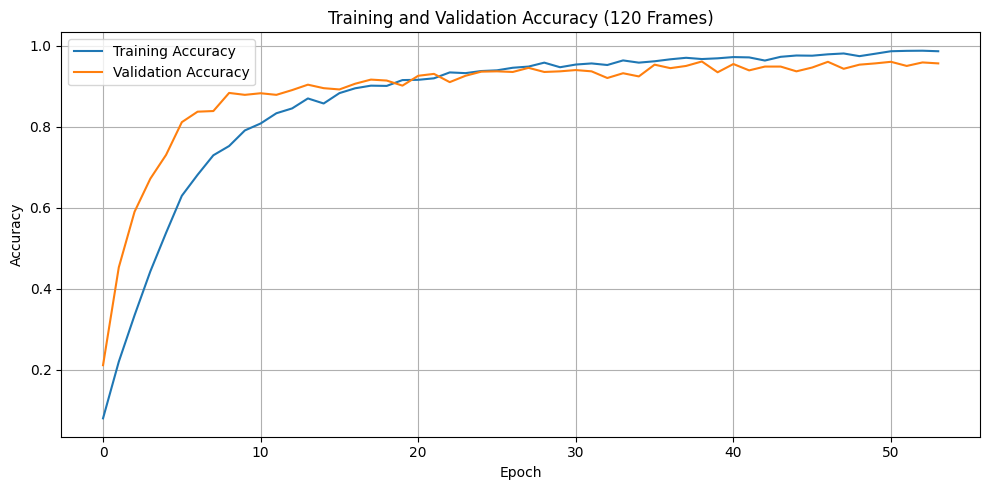

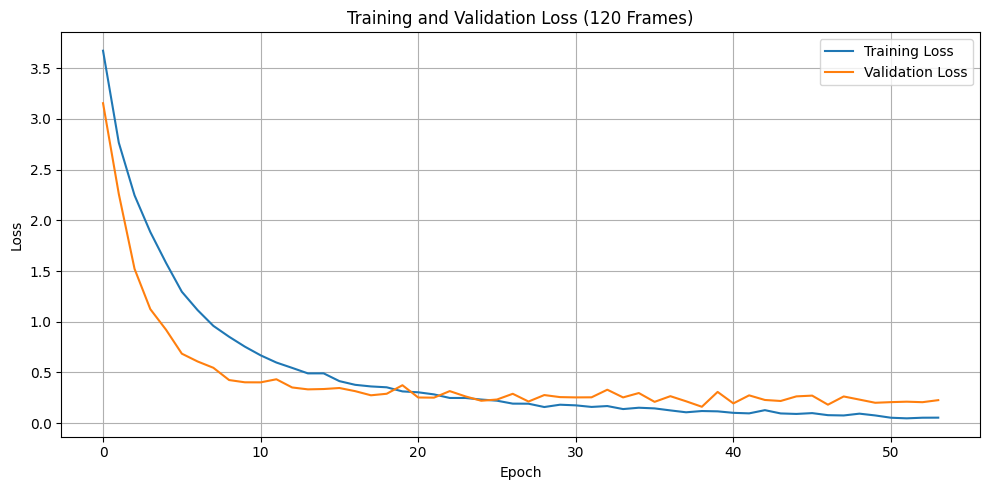


TEST EVALUATION
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.9447 - loss: 0.2675

Test Loss     : 0.267516
Test Accuracy : 0.944719
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step

CLASSIFICATION REPORT
                                  precision    recall  f1-score   support

                 Good to See You       1.00      0.88      0.94        33
                           Leave       0.64      1.00      0.78        28
                          Please       0.88      0.94      0.91        32
                 What Time is It       0.96      0.87      0.92        31
               Where Do You Live       1.00      0.97      0.98        31
                  abar dekha hbe       1.00      0.95      0.97        38
                    ami dukkhito       1.00      1.00      1.00        30
                   ami valo achi       0.90      0.96      0.93        28
        apnake amar valo legeche       1.00      0.97      0.98        31
apnake kivabe sahajjo korte pari       1.00      0.9

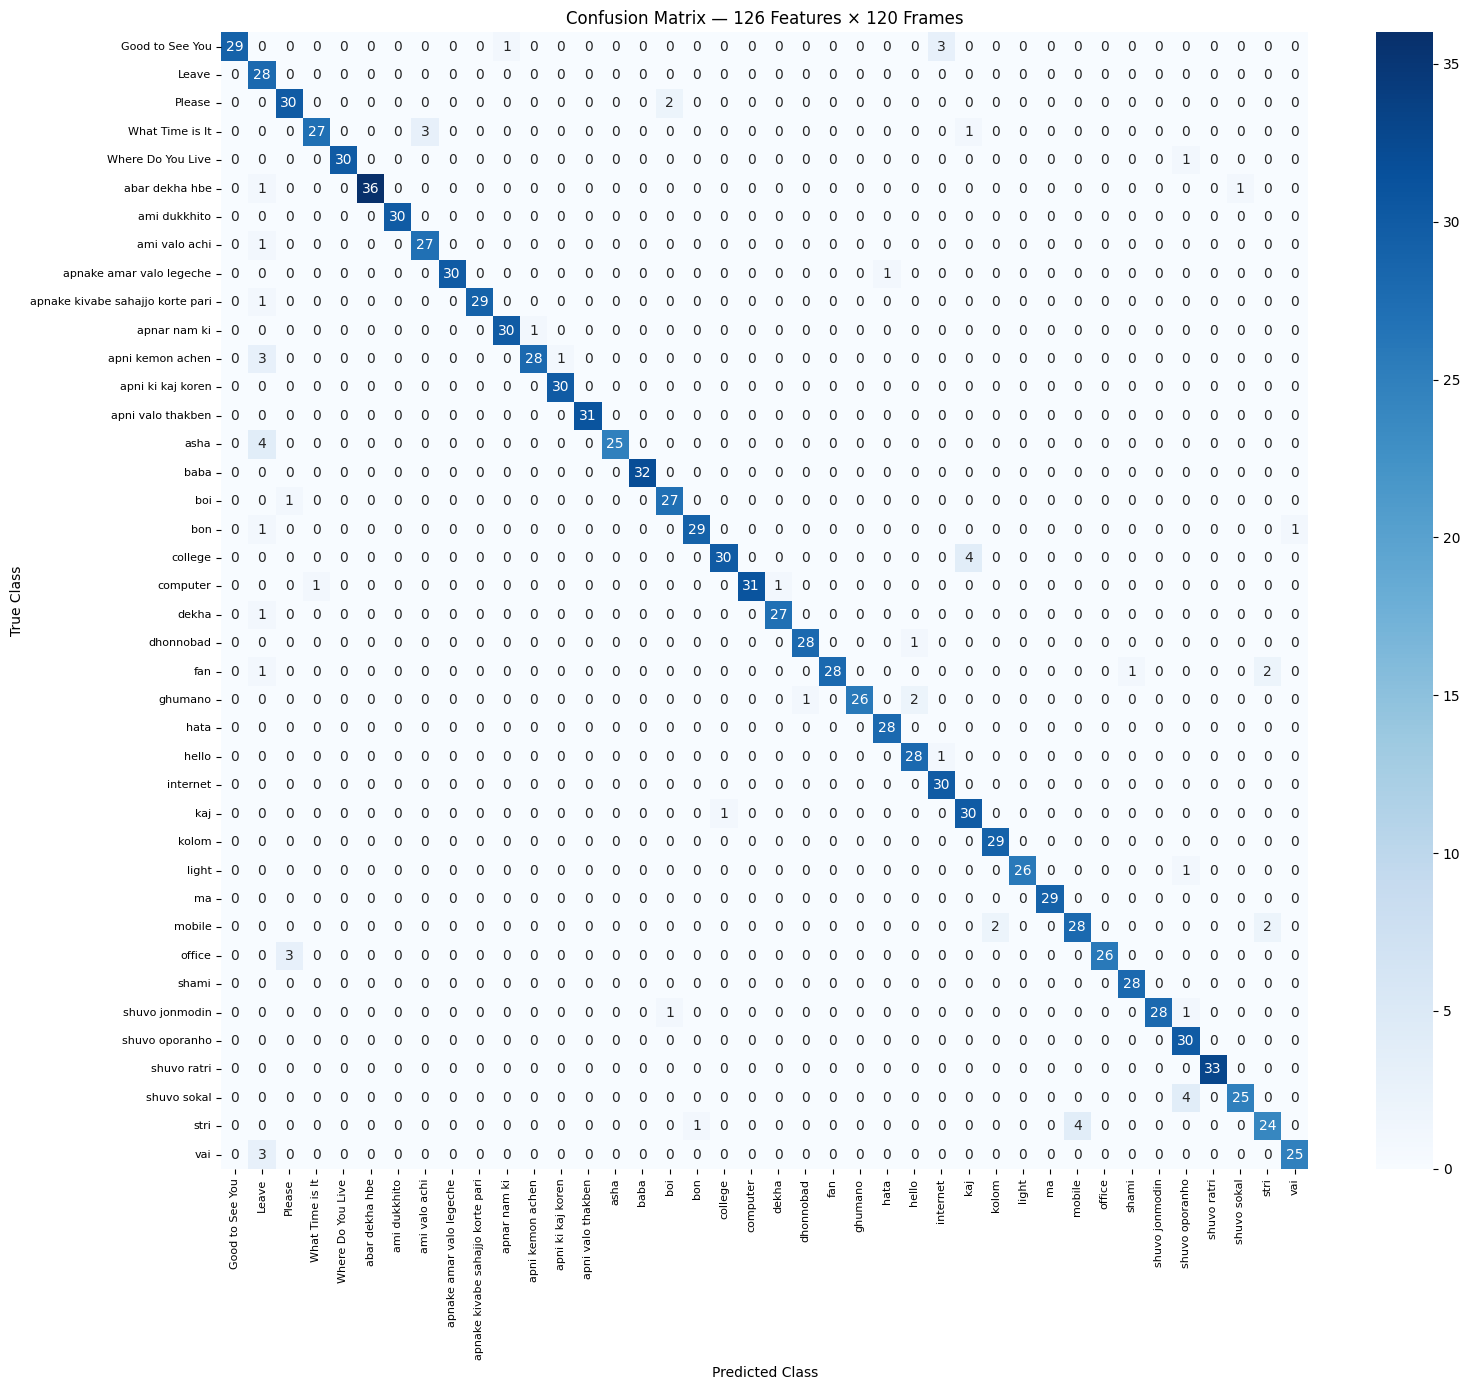

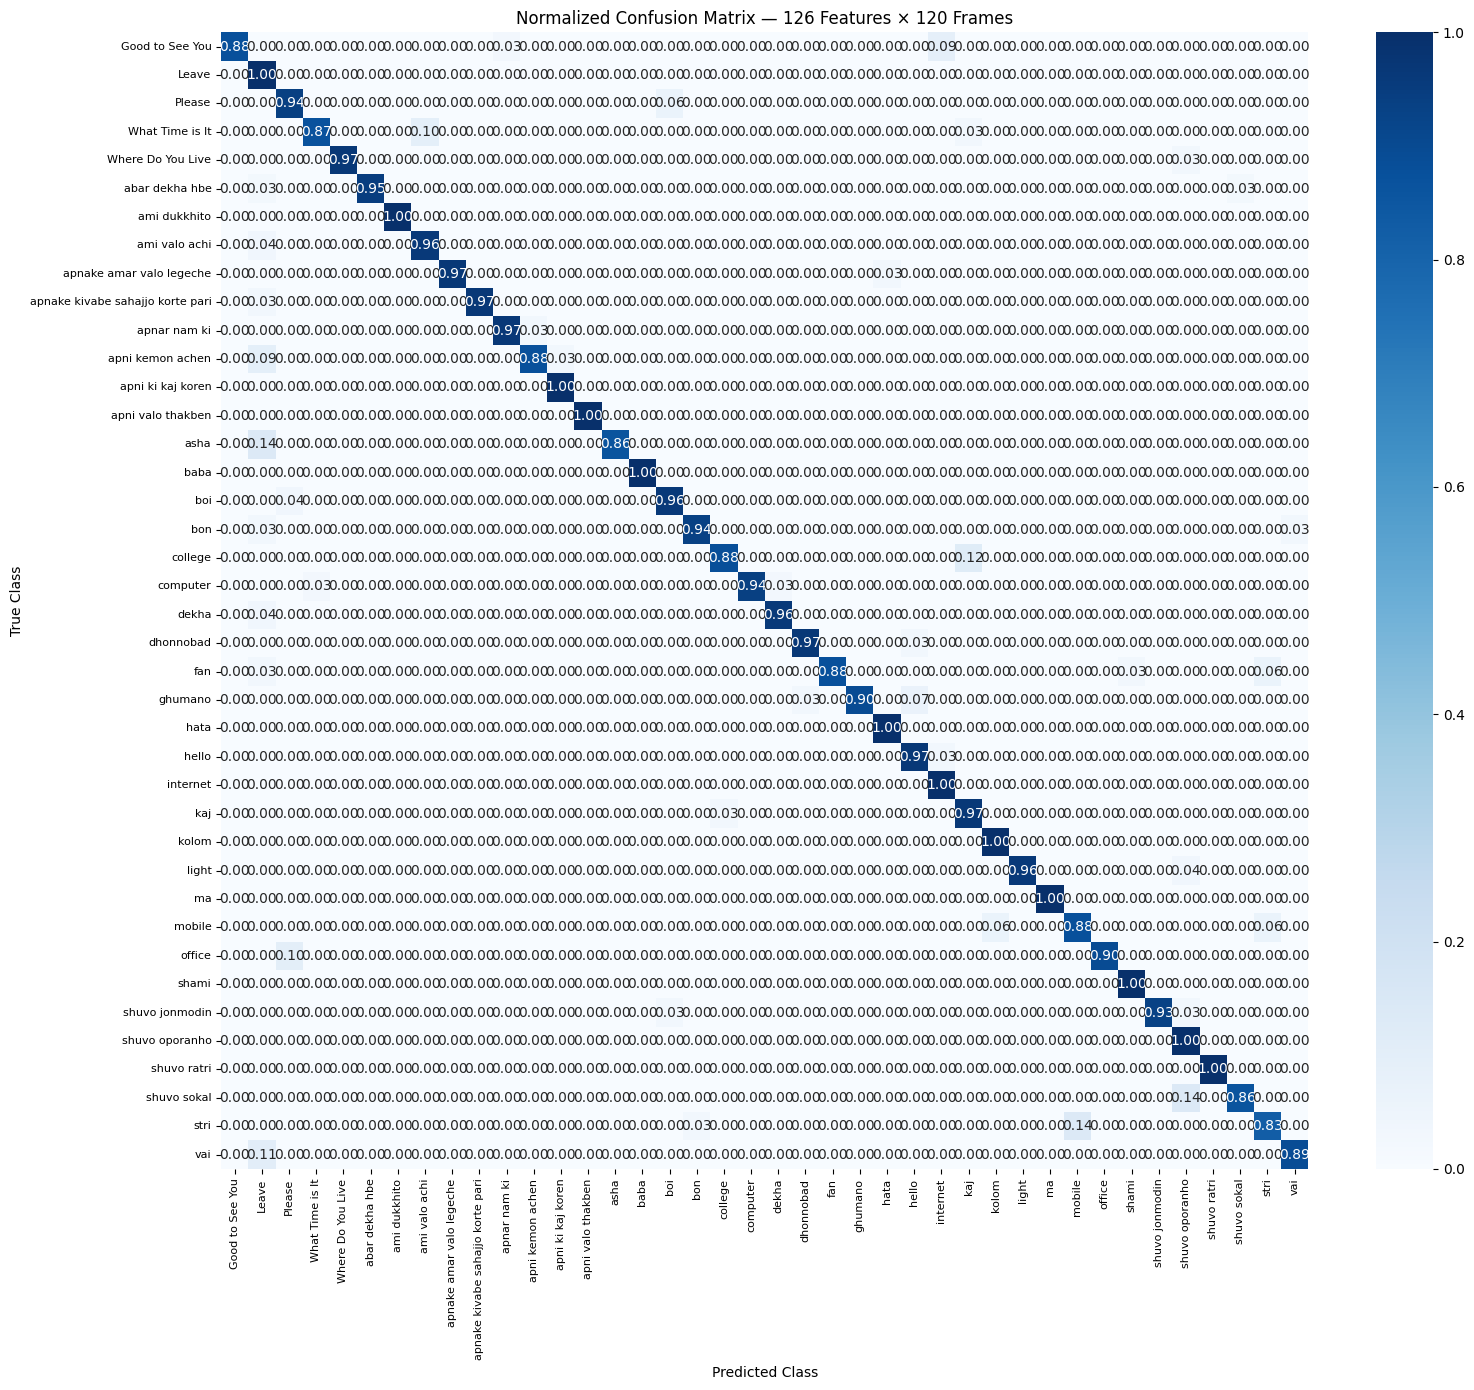


STAGE 2 FINAL SUMMARY (IN-MEMORY)

Experiment:
126 Features × 120 Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
40

Training Samples:
6179

Validation Samples:
1275

Testing Samples:
1212

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
0.267516

Test Accuracy:
0.944719

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
39

Best Validation Accuracy:
0.960784

Best Validation Loss:
0.161365

Training Time:
175.54 minutes



STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)
Test Accuracy: 0.9447
Best Validation Accuracy: 0.9608
Done.


In [2]:


# ============================================================
# ABLATION STUDY — FEATURE CONFIGURATION
# ============================================================
# Change ONLY these four switches for each ablation experiment.
#
# Feature layout (1-based):
#    Left-hand XYZ        : 1–63    -> Python indices 0:63
#    Right-hand XYZ       : 64–126  -> Python indices 63:126
#    Wrist distances     : 127–128 -> Python indices 126:128
#    Elbow distances     : 129–130 -> Python indices 128:130
#
# True  = include the block
# False = exclude the block

USE_LEFT_HAND = True
USE_RIGHT_HAND = True
USE_WRIST_DISTANCES = False
USE_ELBOW_DISTANCES = False

# Build the selected feature indices automatically.
SELECTED_FEATURE_INDICES = []
FEATURE_BLOCKS = []

if USE_LEFT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(0, 63))
    FEATURE_BLOCKS.append("left_hand")

if USE_RIGHT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(63, 126))
    FEATURE_BLOCKS.append("right_hand")

if USE_WRIST_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(126, 128))
    FEATURE_BLOCKS.append("wrist_distances")

if USE_ELBOW_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(128, 130))
    FEATURE_BLOCKS.append("elbow_distances")

if not SELECTED_FEATURE_INDICES:
    raise ValueError("At least one feature block must be enabled.")

NUM_FEATURES = len(SELECTED_FEATURE_INDICES)
EXPERIMENT_NAME = f"{NUM_FEATURES}F_" + "_".join(FEATURE_BLOCKS)

print("\n" + "=" * 70)
print("FEATURE ABLATION CONFIGURATION")
print("=" * 70)
print("Experiment:", EXPERIMENT_NAME)
print("Target frames:", TARGET_FRAMES)
print("Left hand:", USE_LEFT_HAND)
print("Right hand:", USE_RIGHT_HAND)
print("Wrist distances:", USE_WRIST_DISTANCES)
print("Elbow distances:", USE_ELBOW_DISTANCES)
print("Selected feature indices (0-based):", SELECTED_FEATURE_INDICES)
print("Number of selected features:", NUM_FEATURES)
print("=" * 70)

BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 0.0005

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. CHECK DATASET STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("CHECKING DATASET")
print("=" * 70)

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Train path not found: {TRAIN_PATH}")

if not os.path.exists(VAL_PATH):
    raise FileNotFoundError(f"Validation path not found: {VAL_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Test path not found: {TEST_PATH}")


# ============================================================
# 3. LOAD SEQUENCES WITH FEATURE ABLATION
# ============================================================

def load_and_select_sequences_from_folder(base_path):
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    sequences = []
    labels = []

    print("\nLoading:", base_path)
    print("Classes found:", len(class_names))
    print("Selected feature blocks:", ", ".join(FEATURE_BLOCKS))
    print("Selected feature count:", NUM_FEATURES)

    for class_name in class_names:
        class_path = os.path.join(base_path, class_name)

        video_names = sorted([
            d for d in os.listdir(class_path)
            if os.path.isdir(os.path.join(class_path, d))
        ])

        print(
            f"{class_name:<35} "
            f"{len(video_names):>4} videos"
        )

        for video_name in video_names:
            video_path = os.path.join(class_path, video_name)

            frames = []
            valid_video = True

            for frame_num in range(1, ORIGINAL_SEQUENCE_LENGTH + 1):
                frame_file = os.path.join(
                    video_path,
                    f"{frame_num:03d}.npy"
                )

                if not os.path.exists(frame_file):
                    print(f"WARNING: Missing frame: {frame_file}")
                    valid_video = False
                    break

                frame = np.load(frame_file)

                if frame.shape != (130,):
                    print(
                        f"WARNING: Wrong shape: {frame_file} "
                        f"-> {frame.shape}; expected (130,)"
                    )
                    valid_video = False
                    break

                selected_frame = frame[SELECTED_FEATURE_INDICES]
                frames.append(selected_frame)

            if not valid_video:
                print(
                    f"Skipping incomplete video: "
                    f"{class_name}/{video_name}"
                )
                continue

            video_stack = np.stack(frames)
            sequences.append(video_stack)
            labels.append(class_name)

    X = np.asarray(sequences, dtype=np.float32)
    y = np.asarray(labels)

    print("\nLoaded:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, class_names


# ============================================================
# 4. LOAD TRAIN / VALIDATION / TEST
# ============================================================

start_loading = time.time()

X_train, y_train, train_classes = load_and_select_sequences_from_folder(TRAIN_PATH)
X_val, y_val, val_classes = load_and_select_sequences_from_folder(VAL_PATH)
X_test, y_test, test_classes = load_and_select_sequences_from_folder(TEST_PATH)

print(
    f"\nTotal loading and slicing time: "
    f"{time.time() - start_loading:.2f} seconds"
)


# ============================================================
# 5. BASIC DATA CHECKS
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("Train classes:", len(train_classes))
print("Val classes  :", len(val_classes))
print("Test classes :", len(test_classes))

if X_train.ndim != 3:
    raise ValueError("X_train must be 3-dimensional.")

if X_train.shape[1] != TARGET_FRAMES:
    raise ValueError(
        f"Expected {TARGET_FRAMES} frames after slicing, "
        f"got {X_train.shape[1]}"
    )

if X_train.shape[2] != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} selected features, "
        f"got {X_train.shape[2]}"
    )

if len(train_classes) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} classes, "
        f"found {len(train_classes)}"
    )


# ============================================================
# 6. COMBINE CLASS NAMES
# ============================================================

actions = sorted(
    list(
        set(train_classes)
        | set(val_classes)
        | set(test_classes)
    )
)

print("\nFinal classes:", len(actions))

if len(actions) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} total classes, "
        f"found {len(actions)}"
    )

print("\nClass list:")
for i, action in enumerate(actions):
    print(f"{i:02d}: {action}")


# ============================================================
# 7. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()
label_encoder.fit(actions)

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("\nEncoded labels:")
print("Train:", y_train_encoded.shape)
print("Val  :", y_val_encoded.shape)
print("Test :", y_test_encoded.shape)


# ============================================================
# 8. CLASS DISTRIBUTION PRINT AND PLOT
# ============================================================

def print_and_plot_class_distribution(labels, split_name):
    counts = Counter(labels)
    print(f"\n--- {split_name.upper()} Class Distribution ---")
    for class_name in actions:
        print(f"{class_name}: {counts.get(class_name, 0)} videos")

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(actions)), [counts.get(a, 0) for a in actions])
    plt.xticks(range(len(actions)), actions, rotation=90)
    plt.xlabel("Class")
    plt.ylabel("Number of Videos")
    plt.title(f"{split_name.capitalize()} Class Distribution ({TARGET_FRAMES} Frames)")
    plt.tight_layout()
    plt.show()

print_and_plot_class_distribution(y_train, "train")
print_and_plot_class_distribution(y_val, "validation")
print_and_plot_class_distribution(y_test, "test")


# ============================================================
# 9. STANDARDIZATION
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZATION")
print("=" * 70)

scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, NUM_FEATURES)
X_val_flat = X_val.reshape(-1, NUM_FEATURES)
X_test_flat = X_test.reshape(-1, NUM_FEATURES)

print("Fitting scaler on training data...")
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)

print("Transforming validation data...")
X_val_scaled = scaler.transform(X_val_flat).reshape(X_val.shape)

print("Transforming test data...")
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

print("Scaling completed.")


# ============================================================
# 10. ONE-HOT ENCODING
# ============================================================

y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=len(actions))
y_val_cat = tf.keras.utils.to_categorical(y_val_encoded, num_classes=len(actions))
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(actions))


# ============================================================
# 11. BUILD MODEL
# ============================================================

print("\n" + "=" * 70)
print("BUILDING MODEL")
print("=" * 70)

inp = Input(shape=(TARGET_FRAMES, NUM_FEATURES))

x = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inp)
x = BatchNormalization()(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

query = Dense(64)(x)
value = Dense(64)(x)

x = Attention()([query, value])
x = GlobalAveragePooling1D()(x)

x = Dense(128, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

out = Dense(len(actions), activation="softmax")(x)

model = Model(inputs=inp, outputs=out)


# ============================================================
# 12. COMPILE & SUMMARY
# ============================================================

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 13. CALLBACKS (In-Memory Weights Tracking)
# ============================================================

class InMemoryModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_weights = None
        self.best_val_accuracy = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc > self.best_val_accuracy:
            self.best_val_accuracy = val_acc
            self.best_weights = self.model.get_weights()
            print(f"\n[Epoch {epoch + 1}] Validation accuracy improved to {val_acc:.4f}. Weights captured in memory.")

checkpoint_callback = InMemoryModelCheckpoint()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 14. TRAINING
# ============================================================

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

training_start = time.time()

history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        checkpoint_callback,
        reduce_lr
    ],
    verbose=1
)

training_time = time.time() - training_start

print(f"\nTraining completed in {training_time / 60:.2f} minutes")

if checkpoint_callback.best_weights is not None:
    model.set_weights(checkpoint_callback.best_weights)
    print("Loaded best weights captured during training.")


# ============================================================
# 15. TRAINING ACCURACY & LOSS PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Training and Validation Accuracy ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 16. TEST EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("TEST EVALUATION")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test_cat,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.6f}")
print(f"Test Accuracy : {test_accuracy:.6f}")


# ============================================================
# 17. PREDICTIONS & METRICS
# ============================================================

y_prob = model.predict(X_test_scaled, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

report_text = classification_report(
    y_test_encoded,
    y_pred,
    target_names=actions,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report_text)


# ============================================================
# 19. CONFUSION MATRIX PLOTS
# ============================================================

cm = confusion_matrix(
    y_test_encoded,
    y_pred,
    labels=range(len(actions))
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

cm_normalized = (
    cm.astype(np.float64)
    / cm.sum(axis=1, keepdims=True)
)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Normalized Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 20. FINAL SUMMARY DISPLAY
# ============================================================

summary_text = f"""
============================================================
STAGE 2 FINAL SUMMARY (IN-MEMORY)
============================================================

Experiment:
{NUM_FEATURES} Features × {TARGET_FRAMES} Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
{len(actions)}

Training Samples:
{len(X_train)}

Validation Samples:
{len(X_val)}

Testing Samples:
{len(X_test)}

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
{test_loss:.6f}

Test Accuracy:
{test_accuracy:.6f}

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
{best_epoch}

Best Validation Accuracy:
{best_val_accuracy:.6f}

Best Validation Loss:
{best_val_loss:.6f}

Training Time:
{training_time / 60:.2f} minutes

============================================================
"""

print(summary_text)

print("\n" + "=" * 70)
print("STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)")
print("=" * 70)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print("Done.")

exclude elbow


FEATURE ABLATION CONFIGURATION
Experiment: 128F_left_hand_right_hand_wrist_distances
Target frames: 120
Left hand: True
Right hand: True
Wrist distances: True
Elbow distances: False
Selected feature indices (0-based): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127]
Number of selected features: 128

CHECKING DATASET
Train path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\train_csv
Validation path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\validation_csv
Test path: D:\aaa E

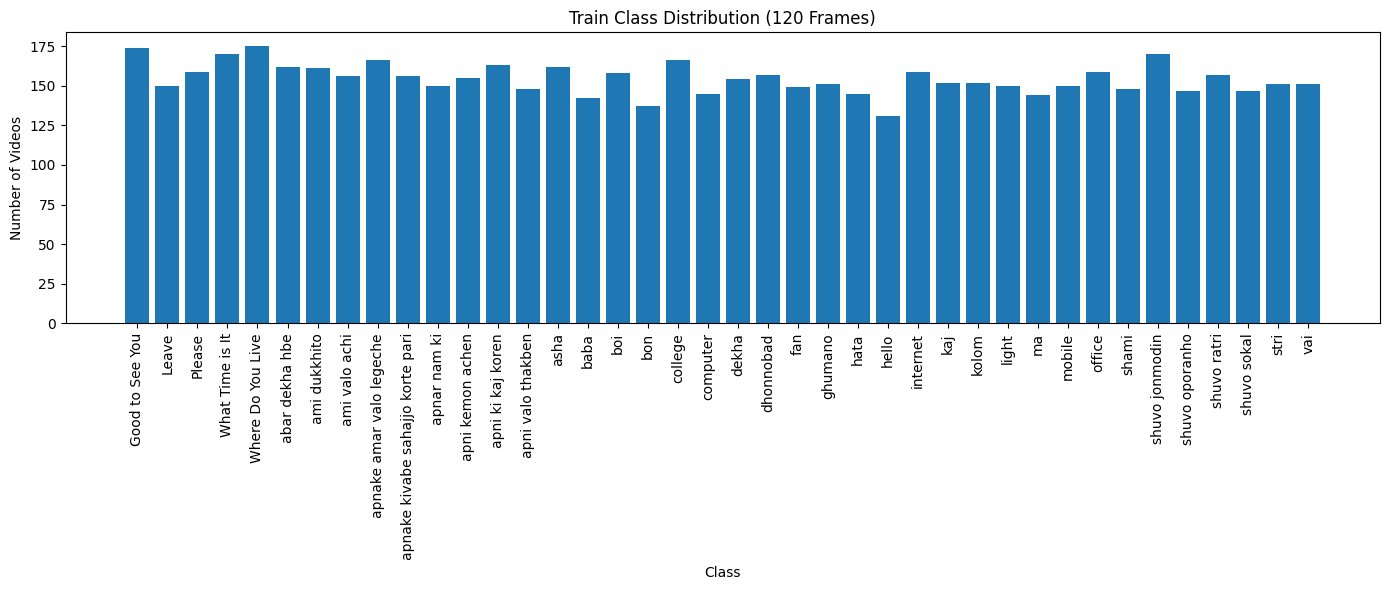


--- VALIDATION Class Distribution ---
Good to See You: 27 videos
Leave: 35 videos
Please: 29 videos
What Time is It: 28 videos
Where Do You Live: 38 videos
abar dekha hbe: 31 videos
ami dukkhito: 31 videos
ami valo achi: 28 videos
apnake amar valo legeche: 29 videos
apnake kivabe sahajjo korte pari: 31 videos
apnar nam ki: 32 videos
apni kemon achen: 35 videos
apni ki kaj koren: 33 videos
apni valo thakben: 33 videos
asha: 34 videos
baba: 30 videos
boi: 33 videos
bon: 31 videos
college: 31 videos
computer: 37 videos
dekha: 33 videos
dhonnobad: 27 videos
fan: 32 videos
ghumano: 31 videos
hata: 30 videos
hello: 30 videos
internet: 34 videos
kaj: 29 videos
kolom: 37 videos
light: 41 videos
ma: 31 videos
mobile: 29 videos
office: 31 videos
shami: 30 videos
shuvo jonmodin: 34 videos
shuvo oporanho: 30 videos
shuvo ratri: 34 videos
shuvo sokal: 38 videos
stri: 29 videos
vai: 29 videos


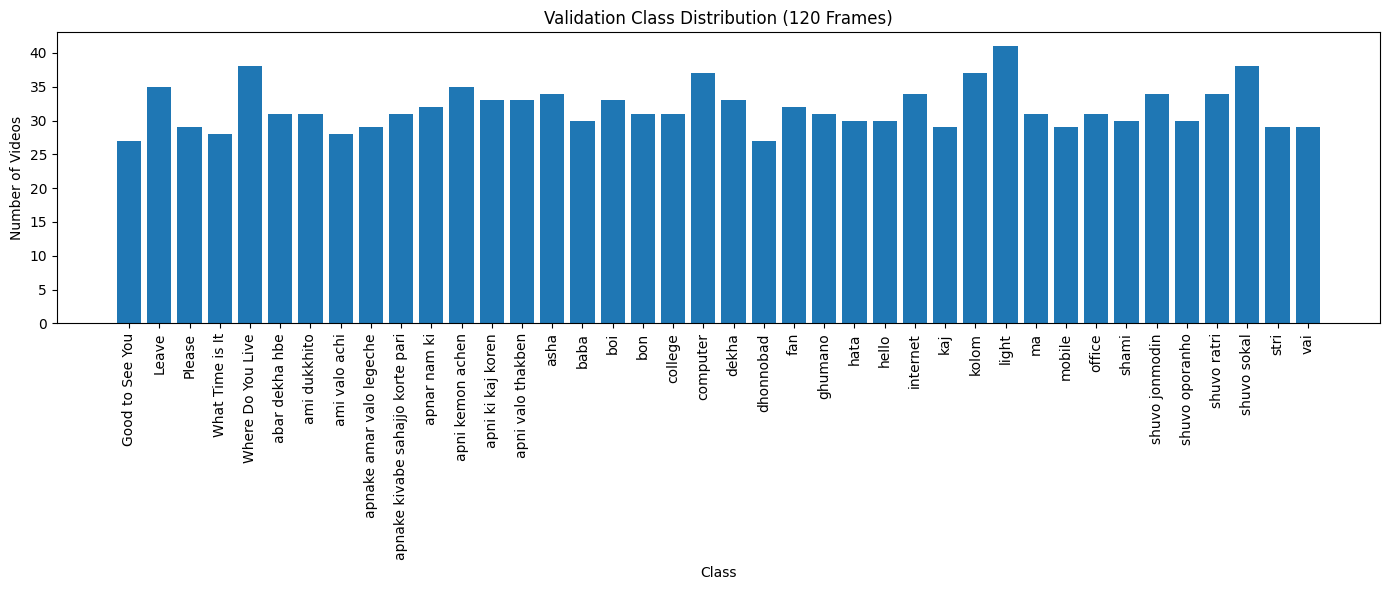


--- TEST Class Distribution ---
Good to See You: 33 videos
Leave: 28 videos
Please: 32 videos
What Time is It: 31 videos
Where Do You Live: 31 videos
abar dekha hbe: 38 videos
ami dukkhito: 30 videos
ami valo achi: 28 videos
apnake amar valo legeche: 31 videos
apnake kivabe sahajjo korte pari: 30 videos
apnar nam ki: 31 videos
apni kemon achen: 32 videos
apni ki kaj koren: 30 videos
apni valo thakben: 31 videos
asha: 29 videos
baba: 32 videos
boi: 28 videos
bon: 31 videos
college: 34 videos
computer: 33 videos
dekha: 28 videos
dhonnobad: 29 videos
fan: 32 videos
ghumano: 29 videos
hata: 28 videos
hello: 29 videos
internet: 30 videos
kaj: 31 videos
kolom: 29 videos
light: 27 videos
ma: 29 videos
mobile: 32 videos
office: 29 videos
shami: 28 videos
shuvo jonmodin: 30 videos
shuvo oporanho: 30 videos
shuvo ratri: 33 videos
shuvo sokal: 29 videos
stri: 29 videos
vai: 28 videos


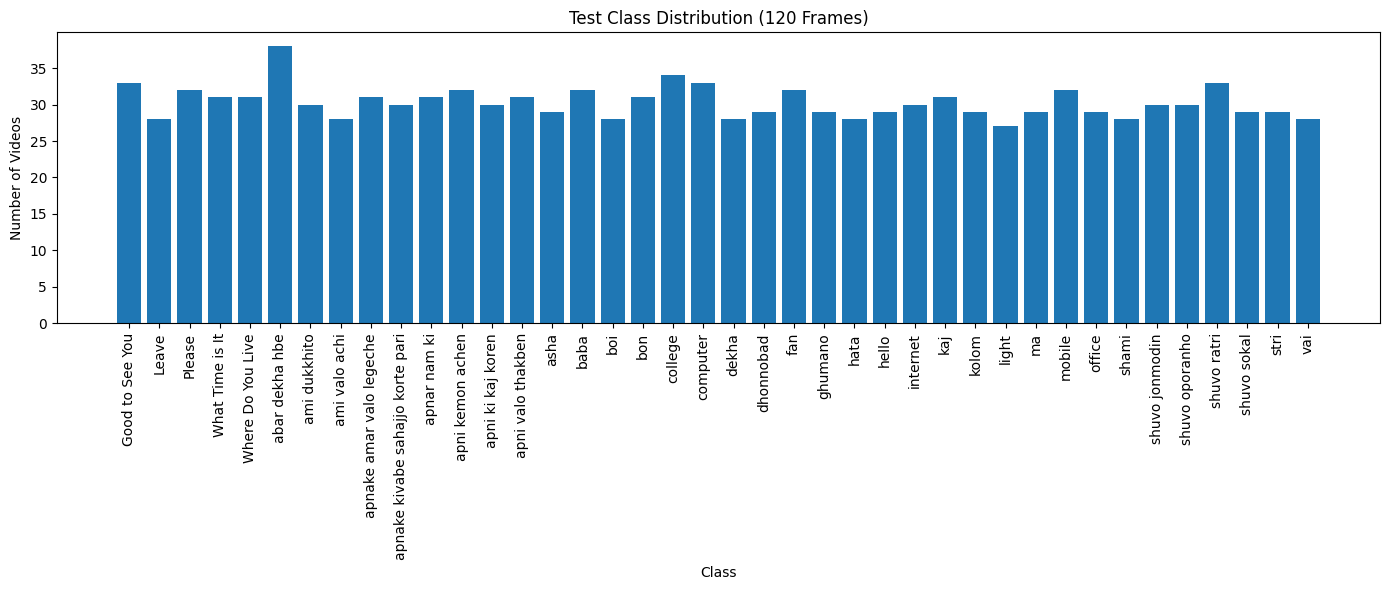


STANDARDIZATION
Fitting scaler on training data...
Transforming validation data...
Transforming test data...
Scaling completed.

BUILDING MODEL


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 120, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 120, 64)   │     24,640 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 120, 256)  │    197,632 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 256)  │      1,024 │ bidirectional_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 120, 256)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 120, 128)  │    164,352 │ dropout_4[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 128)  │        512 │ bidirectional_3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 120, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 120, 64)   │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 120, 64)   │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 120, 64)   │          0 │ dense_5[0][0],    │
│ (Attention)         │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 40)        │      2,600 │ dropout_7[0][0] 

 Total params: 424,872 (1.62 MB)

 Trainable params: 423,592 (1.62 MB)

 Non-trainable params: 1,280 (5.00 KB)


TRAINING
Epoch 1/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0513 - loss: 4.0316
[Epoch 1] Validation accuracy improved to 0.2031. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.0787 - loss: 3.7351 - val_accuracy: 0.2031 - val_loss: 3.2817 - learning_rate: 5.0000e-04
Epoch 2/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1790 - loss: 2.9796
[Epoch 2] Validation accuracy improved to 0.5114. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.2144 - loss: 2.8052 - val_accuracy: 0.5114 - val_loss: 2.1852 - learning_rate: 5.0000e-04
Epoch 3/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3104 - loss: 2.3667
[Epoch 3] Validation accuracy improved to 0.6259. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.3457 - loss: 2.2454 - val_accuracy: 0.6259 - val_loss: 1.4085 - learning_rate: 5.0000e-04
Epoch 4/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4385 - l

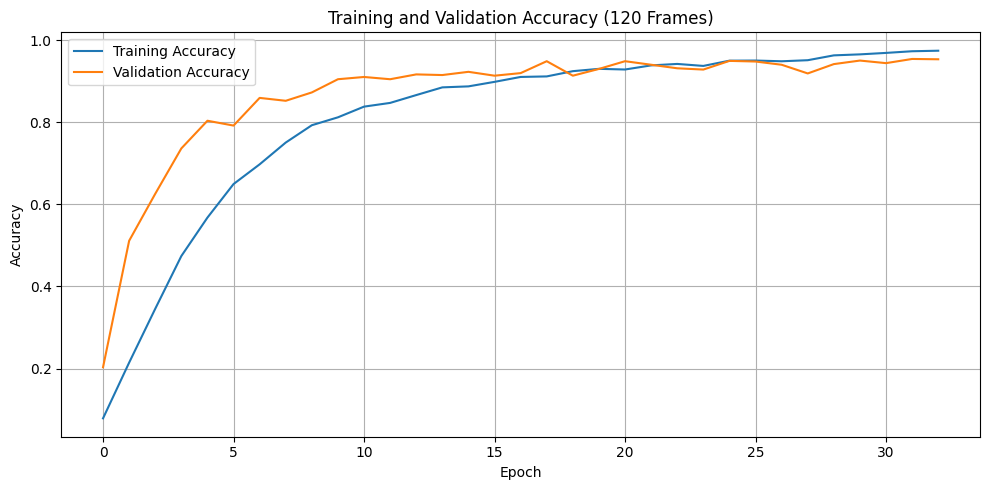

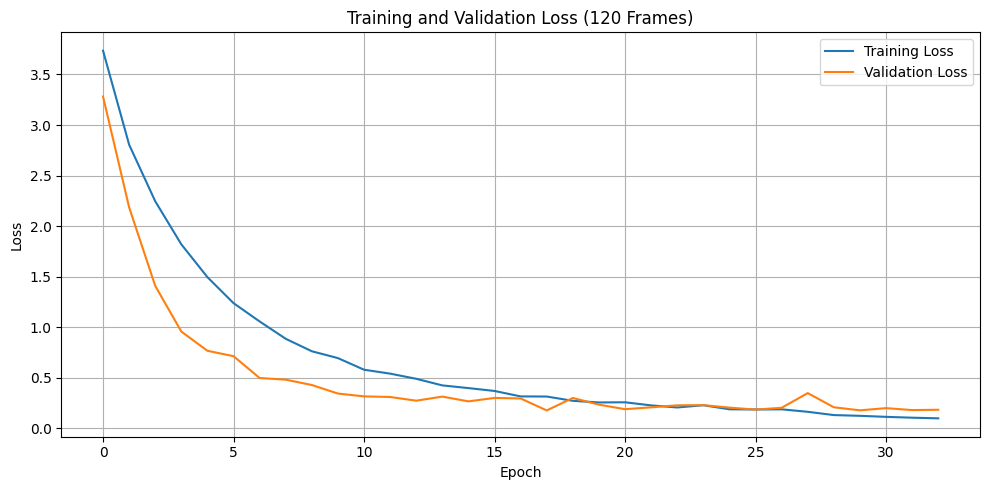


TEST EVALUATION
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.9571 - loss: 0.1881

Test Loss     : 0.188054
Test Accuracy : 0.957096
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 286ms/step

CLASSIFICATION REPORT
                                  precision    recall  f1-score   support

                 Good to See You       1.00      0.94      0.97        33
                           Leave       0.76      1.00      0.86        28
                          Please       0.86      0.94      0.90        32
                 What Time is It       1.00      0.97      0.98        31
               Where Do You Live       1.00      0.97      0.98        31
                  abar dekha hbe       1.00      0.97      0.99        38
                    ami dukkhito       1.00      1.00      1.00        30
                   ami valo achi       1.00      1.00      1.00        28
        apnake amar valo legeche       1.00      1.00      1.00        31
apnake kivabe sahajjo korte pari       1.00      0.9

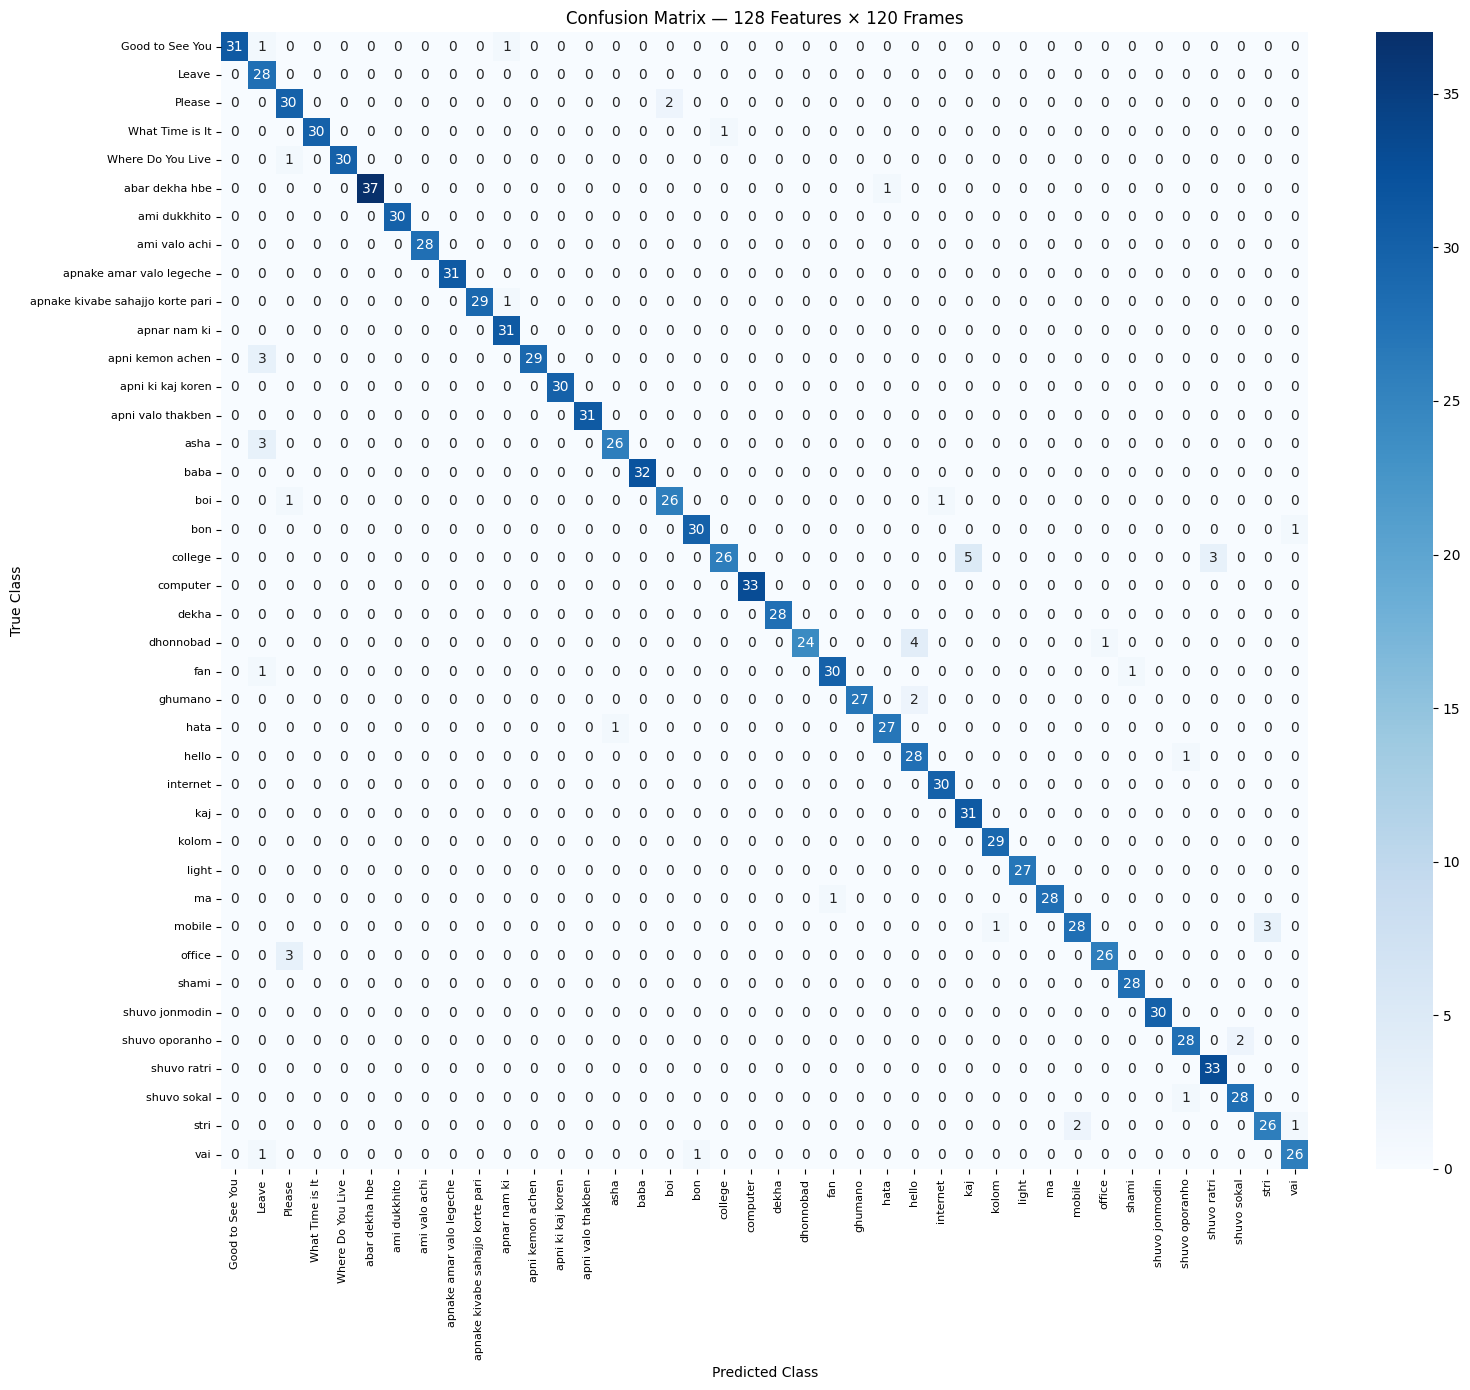

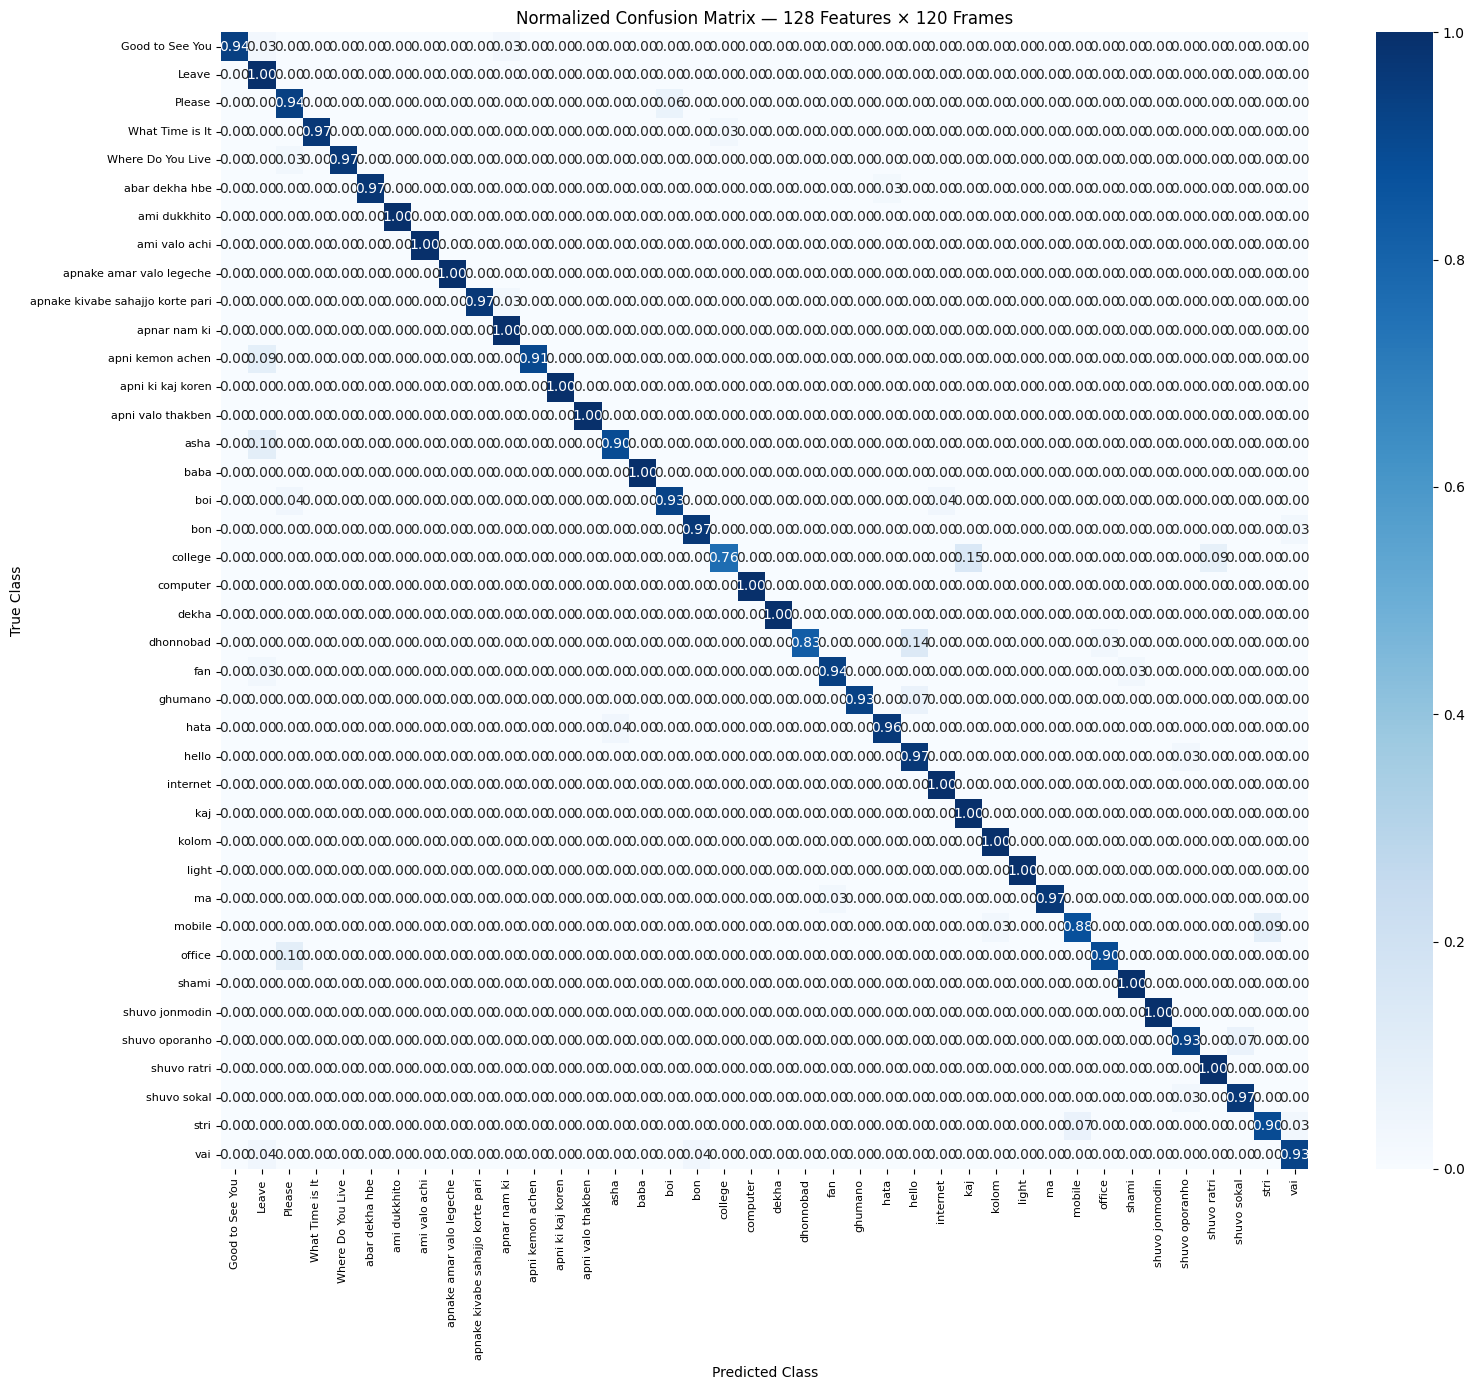


STAGE 2 FINAL SUMMARY (IN-MEMORY)

Experiment:
128 Features × 120 Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
40

Training Samples:
6179

Validation Samples:
1275

Testing Samples:
1212

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
0.188054

Test Accuracy:
0.957096

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
32

Best Validation Accuracy:
0.954510

Best Validation Loss:
0.176010

Training Time:
113.08 minutes



STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)
Test Accuracy: 0.9571
Best Validation Accuracy: 0.9545
Done.


In [3]:


# ============================================================
# ABLATION STUDY — FEATURE CONFIGURATION
# ============================================================
# Change ONLY these four switches for each ablation experiment.
#
# Feature layout (1-based):
#    Left-hand XYZ        : 1–63    -> Python indices 0:63
#    Right-hand XYZ       : 64–126  -> Python indices 63:126
#    Wrist distances     : 127–128 -> Python indices 126:128
#    Elbow distances     : 129–130 -> Python indices 128:130
#
# True  = include the block
# False = exclude the block

USE_LEFT_HAND = True
USE_RIGHT_HAND = True
USE_WRIST_DISTANCES = True
USE_ELBOW_DISTANCES = False

# Build the selected feature indices automatically.
SELECTED_FEATURE_INDICES = []
FEATURE_BLOCKS = []

if USE_LEFT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(0, 63))
    FEATURE_BLOCKS.append("left_hand")

if USE_RIGHT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(63, 126))
    FEATURE_BLOCKS.append("right_hand")

if USE_WRIST_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(126, 128))
    FEATURE_BLOCKS.append("wrist_distances")

if USE_ELBOW_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(128, 130))
    FEATURE_BLOCKS.append("elbow_distances")

if not SELECTED_FEATURE_INDICES:
    raise ValueError("At least one feature block must be enabled.")

NUM_FEATURES = len(SELECTED_FEATURE_INDICES)
EXPERIMENT_NAME = f"{NUM_FEATURES}F_" + "_".join(FEATURE_BLOCKS)

print("\n" + "=" * 70)
print("FEATURE ABLATION CONFIGURATION")
print("=" * 70)
print("Experiment:", EXPERIMENT_NAME)
print("Target frames:", TARGET_FRAMES)
print("Left hand:", USE_LEFT_HAND)
print("Right hand:", USE_RIGHT_HAND)
print("Wrist distances:", USE_WRIST_DISTANCES)
print("Elbow distances:", USE_ELBOW_DISTANCES)
print("Selected feature indices (0-based):", SELECTED_FEATURE_INDICES)
print("Number of selected features:", NUM_FEATURES)
print("=" * 70)

BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 0.0005

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. CHECK DATASET STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("CHECKING DATASET")
print("=" * 70)

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Train path not found: {TRAIN_PATH}")

if not os.path.exists(VAL_PATH):
    raise FileNotFoundError(f"Validation path not found: {VAL_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Test path not found: {TEST_PATH}")


# ============================================================
# 3. LOAD SEQUENCES WITH FEATURE ABLATION
# ============================================================

def load_and_select_sequences_from_folder(base_path):
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    sequences = []
    labels = []

    print("\nLoading:", base_path)
    print("Classes found:", len(class_names))
    print("Selected feature blocks:", ", ".join(FEATURE_BLOCKS))
    print("Selected feature count:", NUM_FEATURES)

    for class_name in class_names:
        class_path = os.path.join(base_path, class_name)

        video_names = sorted([
            d for d in os.listdir(class_path)
            if os.path.isdir(os.path.join(class_path, d))
        ])

        print(
            f"{class_name:<35} "
            f"{len(video_names):>4} videos"
        )

        for video_name in video_names:
            video_path = os.path.join(class_path, video_name)

            frames = []
            valid_video = True

            for frame_num in range(1, ORIGINAL_SEQUENCE_LENGTH + 1):
                frame_file = os.path.join(
                    video_path,
                    f"{frame_num:03d}.npy"
                )

                if not os.path.exists(frame_file):
                    print(f"WARNING: Missing frame: {frame_file}")
                    valid_video = False
                    break

                frame = np.load(frame_file)

                if frame.shape != (130,):
                    print(
                        f"WARNING: Wrong shape: {frame_file} "
                        f"-> {frame.shape}; expected (130,)"
                    )
                    valid_video = False
                    break

                selected_frame = frame[SELECTED_FEATURE_INDICES]
                frames.append(selected_frame)

            if not valid_video:
                print(
                    f"Skipping incomplete video: "
                    f"{class_name}/{video_name}"
                )
                continue

            video_stack = np.stack(frames)
            sequences.append(video_stack)
            labels.append(class_name)

    X = np.asarray(sequences, dtype=np.float32)
    y = np.asarray(labels)

    print("\nLoaded:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, class_names


# ============================================================
# 4. LOAD TRAIN / VALIDATION / TEST
# ============================================================

start_loading = time.time()

X_train, y_train, train_classes = load_and_select_sequences_from_folder(TRAIN_PATH)
X_val, y_val, val_classes = load_and_select_sequences_from_folder(VAL_PATH)
X_test, y_test, test_classes = load_and_select_sequences_from_folder(TEST_PATH)

print(
    f"\nTotal loading and slicing time: "
    f"{time.time() - start_loading:.2f} seconds"
)


# ============================================================
# 5. BASIC DATA CHECKS
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("Train classes:", len(train_classes))
print("Val classes  :", len(val_classes))
print("Test classes :", len(test_classes))

if X_train.ndim != 3:
    raise ValueError("X_train must be 3-dimensional.")

if X_train.shape[1] != TARGET_FRAMES:
    raise ValueError(
        f"Expected {TARGET_FRAMES} frames after slicing, "
        f"got {X_train.shape[1]}"
    )

if X_train.shape[2] != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} selected features, "
        f"got {X_train.shape[2]}"
    )

if len(train_classes) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} classes, "
        f"found {len(train_classes)}"
    )


# ============================================================
# 6. COMBINE CLASS NAMES
# ============================================================

actions = sorted(
    list(
        set(train_classes)
        | set(val_classes)
        | set(test_classes)
    )
)

print("\nFinal classes:", len(actions))

if len(actions) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} total classes, "
        f"found {len(actions)}"
    )

print("\nClass list:")
for i, action in enumerate(actions):
    print(f"{i:02d}: {action}")


# ============================================================
# 7. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()
label_encoder.fit(actions)

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("\nEncoded labels:")
print("Train:", y_train_encoded.shape)
print("Val  :", y_val_encoded.shape)
print("Test :", y_test_encoded.shape)


# ============================================================
# 8. CLASS DISTRIBUTION PRINT AND PLOT
# ============================================================

def print_and_plot_class_distribution(labels, split_name):
    counts = Counter(labels)
    print(f"\n--- {split_name.upper()} Class Distribution ---")
    for class_name in actions:
        print(f"{class_name}: {counts.get(class_name, 0)} videos")

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(actions)), [counts.get(a, 0) for a in actions])
    plt.xticks(range(len(actions)), actions, rotation=90)
    plt.xlabel("Class")
    plt.ylabel("Number of Videos")
    plt.title(f"{split_name.capitalize()} Class Distribution ({TARGET_FRAMES} Frames)")
    plt.tight_layout()
    plt.show()

print_and_plot_class_distribution(y_train, "train")
print_and_plot_class_distribution(y_val, "validation")
print_and_plot_class_distribution(y_test, "test")


# ============================================================
# 9. STANDARDIZATION
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZATION")
print("=" * 70)

scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, NUM_FEATURES)
X_val_flat = X_val.reshape(-1, NUM_FEATURES)
X_test_flat = X_test.reshape(-1, NUM_FEATURES)

print("Fitting scaler on training data...")
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)

print("Transforming validation data...")
X_val_scaled = scaler.transform(X_val_flat).reshape(X_val.shape)

print("Transforming test data...")
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

print("Scaling completed.")


# ============================================================
# 10. ONE-HOT ENCODING
# ============================================================

y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=len(actions))
y_val_cat = tf.keras.utils.to_categorical(y_val_encoded, num_classes=len(actions))
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(actions))


# ============================================================
# 11. BUILD MODEL
# ============================================================

print("\n" + "=" * 70)
print("BUILDING MODEL")
print("=" * 70)

inp = Input(shape=(TARGET_FRAMES, NUM_FEATURES))

x = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inp)
x = BatchNormalization()(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

query = Dense(64)(x)
value = Dense(64)(x)

x = Attention()([query, value])
x = GlobalAveragePooling1D()(x)

x = Dense(128, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

out = Dense(len(actions), activation="softmax")(x)

model = Model(inputs=inp, outputs=out)


# ============================================================
# 12. COMPILE & SUMMARY
# ============================================================

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 13. CALLBACKS (In-Memory Weights Tracking)
# ============================================================

class InMemoryModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_weights = None
        self.best_val_accuracy = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc > self.best_val_accuracy:
            self.best_val_accuracy = val_acc
            self.best_weights = self.model.get_weights()
            print(f"\n[Epoch {epoch + 1}] Validation accuracy improved to {val_acc:.4f}. Weights captured in memory.")

checkpoint_callback = InMemoryModelCheckpoint()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 14. TRAINING
# ============================================================

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

training_start = time.time()

history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        checkpoint_callback,
        reduce_lr
    ],
    verbose=1
)

training_time = time.time() - training_start

print(f"\nTraining completed in {training_time / 60:.2f} minutes")

if checkpoint_callback.best_weights is not None:
    model.set_weights(checkpoint_callback.best_weights)
    print("Loaded best weights captured during training.")


# ============================================================
# 15. TRAINING ACCURACY & LOSS PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Training and Validation Accuracy ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 16. TEST EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("TEST EVALUATION")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test_cat,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.6f}")
print(f"Test Accuracy : {test_accuracy:.6f}")


# ============================================================
# 17. PREDICTIONS & METRICS
# ============================================================

y_prob = model.predict(X_test_scaled, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

report_text = classification_report(
    y_test_encoded,
    y_pred,
    target_names=actions,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report_text)


# ============================================================
# 19. CONFUSION MATRIX PLOTS
# ============================================================

cm = confusion_matrix(
    y_test_encoded,
    y_pred,
    labels=range(len(actions))
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

cm_normalized = (
    cm.astype(np.float64)
    / cm.sum(axis=1, keepdims=True)
)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Normalized Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 20. FINAL SUMMARY DISPLAY
# ============================================================

summary_text = f"""
============================================================
STAGE 2 FINAL SUMMARY (IN-MEMORY)
============================================================

Experiment:
{NUM_FEATURES} Features × {TARGET_FRAMES} Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
{len(actions)}

Training Samples:
{len(X_train)}

Validation Samples:
{len(X_val)}

Testing Samples:
{len(X_test)}

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
{test_loss:.6f}

Test Accuracy:
{test_accuracy:.6f}

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
{best_epoch}

Best Validation Accuracy:
{best_val_accuracy:.6f}

Best Validation Loss:
{best_val_loss:.6f}

Training Time:
{training_time / 60:.2f} minutes

============================================================
"""

print(summary_text)

print("\n" + "=" * 70)
print("STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)")
print("=" * 70)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print("Done.")

exclude wrist, include elbow


FEATURE ABLATION CONFIGURATION
Experiment: 128F_left_hand_right_hand_elbow_distances
Target frames: 120
Left hand: True
Right hand: True
Wrist distances: False
Elbow distances: True
Selected feature indices (0-based): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 128, 129]
Number of selected features: 128

CHECKING DATASET
Train path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\train_csv
Validation path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\validation_csv
Test path: D:\aaa E

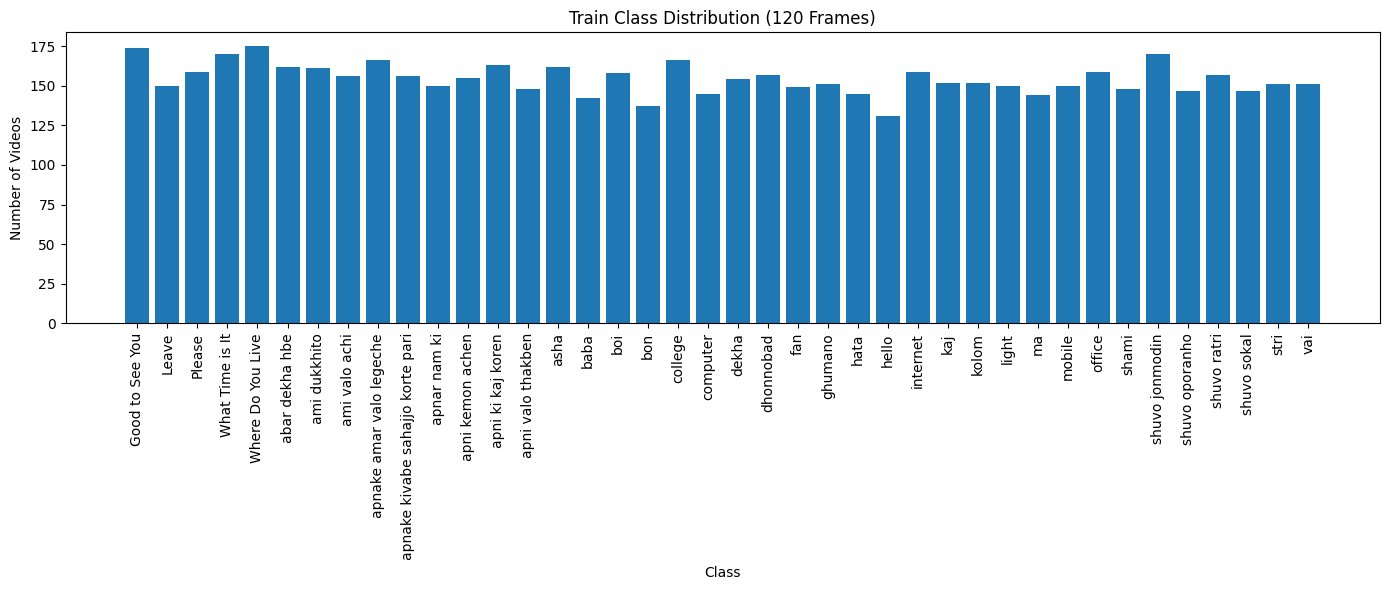


--- VALIDATION Class Distribution ---
Good to See You: 27 videos
Leave: 35 videos
Please: 29 videos
What Time is It: 28 videos
Where Do You Live: 38 videos
abar dekha hbe: 31 videos
ami dukkhito: 31 videos
ami valo achi: 28 videos
apnake amar valo legeche: 29 videos
apnake kivabe sahajjo korte pari: 31 videos
apnar nam ki: 32 videos
apni kemon achen: 35 videos
apni ki kaj koren: 33 videos
apni valo thakben: 33 videos
asha: 34 videos
baba: 30 videos
boi: 33 videos
bon: 31 videos
college: 31 videos
computer: 37 videos
dekha: 33 videos
dhonnobad: 27 videos
fan: 32 videos
ghumano: 31 videos
hata: 30 videos
hello: 30 videos
internet: 34 videos
kaj: 29 videos
kolom: 37 videos
light: 41 videos
ma: 31 videos
mobile: 29 videos
office: 31 videos
shami: 30 videos
shuvo jonmodin: 34 videos
shuvo oporanho: 30 videos
shuvo ratri: 34 videos
shuvo sokal: 38 videos
stri: 29 videos
vai: 29 videos


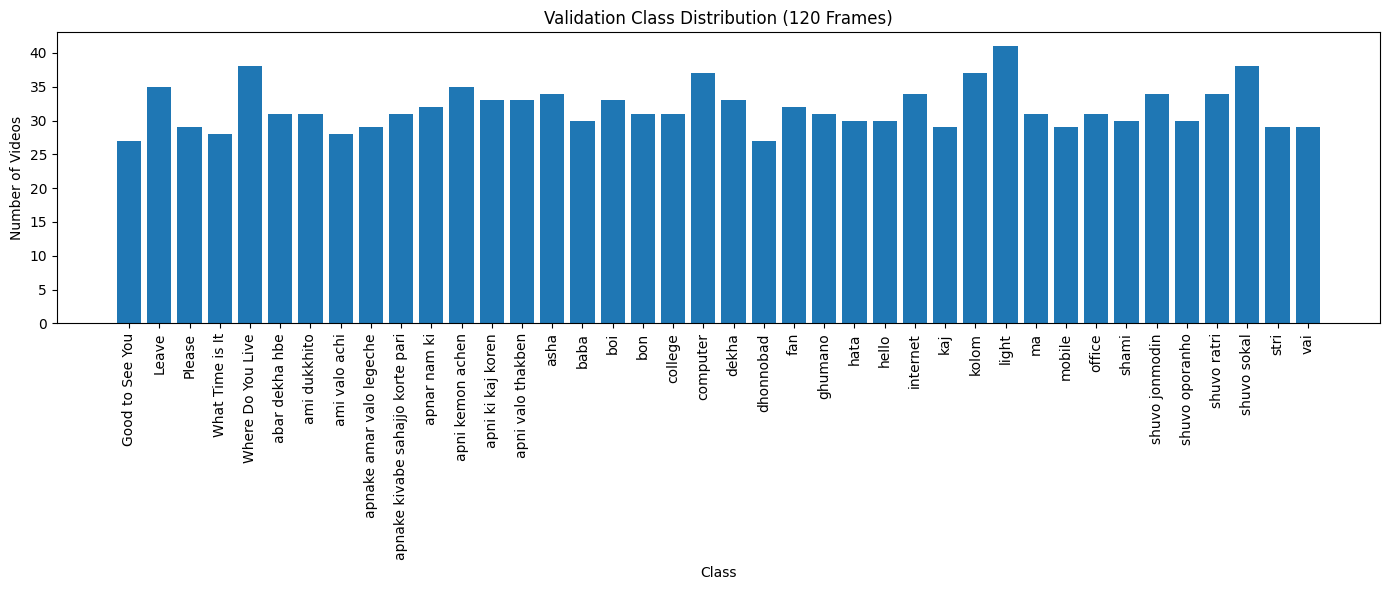


--- TEST Class Distribution ---
Good to See You: 33 videos
Leave: 28 videos
Please: 32 videos
What Time is It: 31 videos
Where Do You Live: 31 videos
abar dekha hbe: 38 videos
ami dukkhito: 30 videos
ami valo achi: 28 videos
apnake amar valo legeche: 31 videos
apnake kivabe sahajjo korte pari: 30 videos
apnar nam ki: 31 videos
apni kemon achen: 32 videos
apni ki kaj koren: 30 videos
apni valo thakben: 31 videos
asha: 29 videos
baba: 32 videos
boi: 28 videos
bon: 31 videos
college: 34 videos
computer: 33 videos
dekha: 28 videos
dhonnobad: 29 videos
fan: 32 videos
ghumano: 29 videos
hata: 28 videos
hello: 29 videos
internet: 30 videos
kaj: 31 videos
kolom: 29 videos
light: 27 videos
ma: 29 videos
mobile: 32 videos
office: 29 videos
shami: 28 videos
shuvo jonmodin: 30 videos
shuvo oporanho: 30 videos
shuvo ratri: 33 videos
shuvo sokal: 29 videos
stri: 29 videos
vai: 28 videos


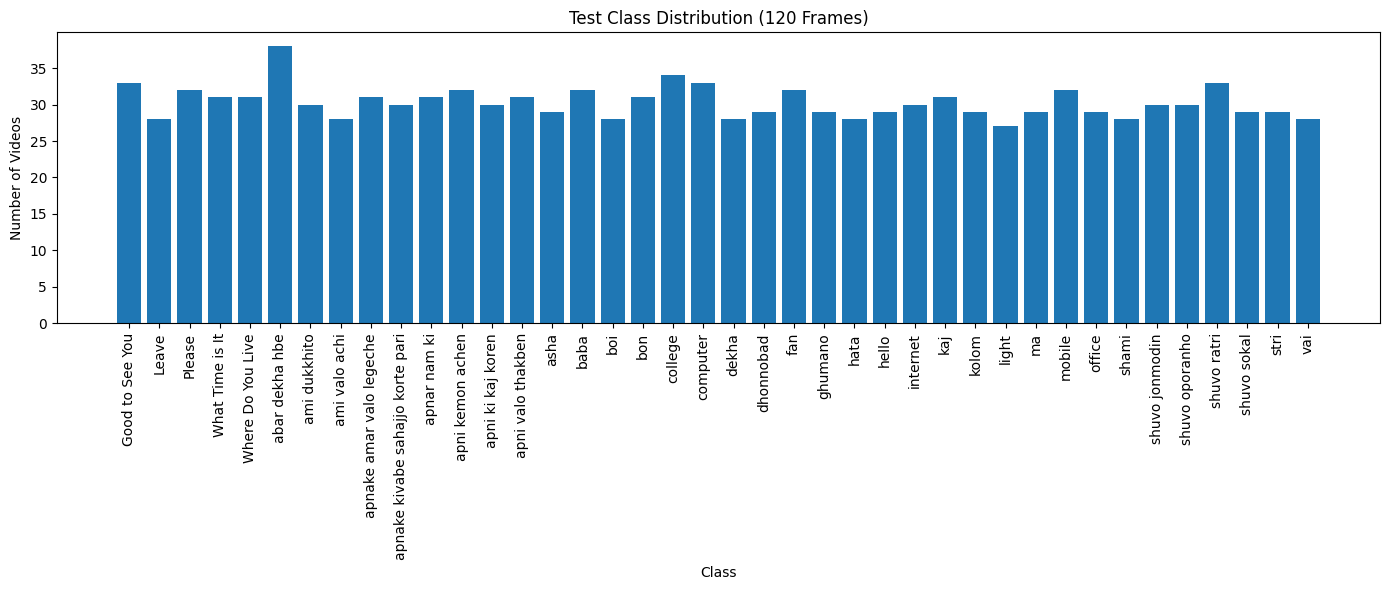


STANDARDIZATION
Fitting scaler on training data...
Transforming validation data...
Transforming test data...
Scaling completed.

BUILDING MODEL


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 120, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 120, 64)   │     24,640 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 120, 256)  │    197,632 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 256)  │      1,024 │ bidirectional_4[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 120, 256)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 120, 128)  │    164,352 │ dropout_8[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 128)  │        512 │ bidirectional_5[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 120, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 120, 64)   │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 120, 64)   │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 120, 64)   │          0 │ dense_10[0][0],   │
│ (Attention)         │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention_2[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_13[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                 

 Total params: 424,872 (1.62 MB)

 Trainable params: 423,592 (1.62 MB)

 Non-trainable params: 1,280 (5.00 KB)


TRAINING
Epoch 1/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0423 - loss: 4.1422
[Epoch 1] Validation accuracy improved to 0.1584. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.0636 - loss: 3.8552 - val_accuracy: 0.1584 - val_loss: 3.2791 - learning_rate: 5.0000e-04
Epoch 2/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1526 - loss: 3.1122
[Epoch 2] Validation accuracy improved to 0.3953. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.1809 - loss: 2.9603 - val_accuracy: 0.3953 - val_loss: 2.2502 - learning_rate: 5.0000e-04
Epoch 3/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2768 - loss: 2.4970
[Epoch 3] Validation accuracy improved to 0.6063. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.3133 - loss: 2.3702 - val_accuracy: 0.6063 - val_loss: 1.5100 - learning_rate: 5.0000e-04
Epoch 4/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4086 - l

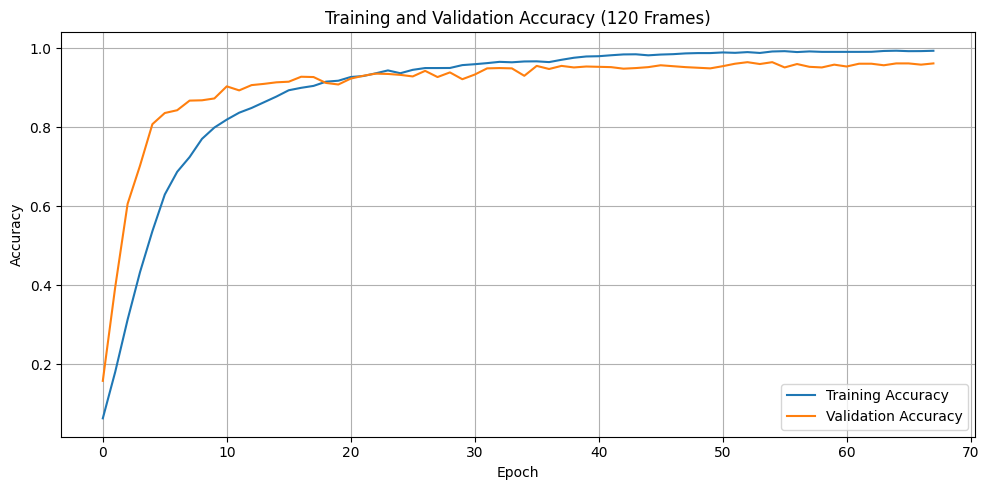

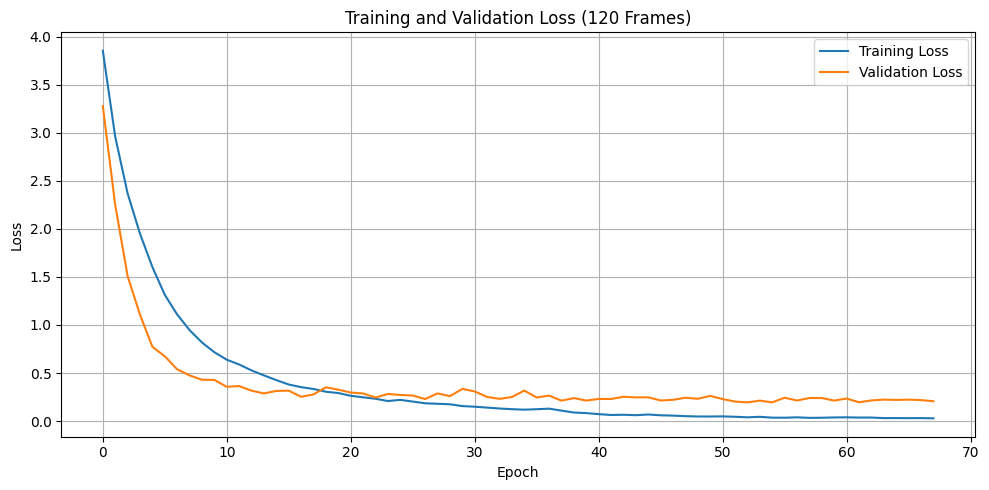


TEST EVALUATION
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9579 - loss: 0.2265

Test Loss     : 0.226457
Test Accuracy : 0.957921
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 251ms/step

CLASSIFICATION REPORT
                                  precision    recall  f1-score   support

                 Good to See You       1.00      0.97      0.98        33
                           Leave       0.73      0.96      0.83        28
                          Please       0.88      0.94      0.91        32
                 What Time is It       0.94      1.00      0.97        31
               Where Do You Live       1.00      0.97      0.98        31
                  abar dekha hbe       1.00      0.97      0.99        38
                    ami dukkhito       1.00      1.00      1.00        30
                   ami valo achi       1.00      0.96      0.98        28
        apnake amar valo legeche       1.00      1.00      1.00        31
apnake kivabe sahajjo korte pari       1.00      0.9

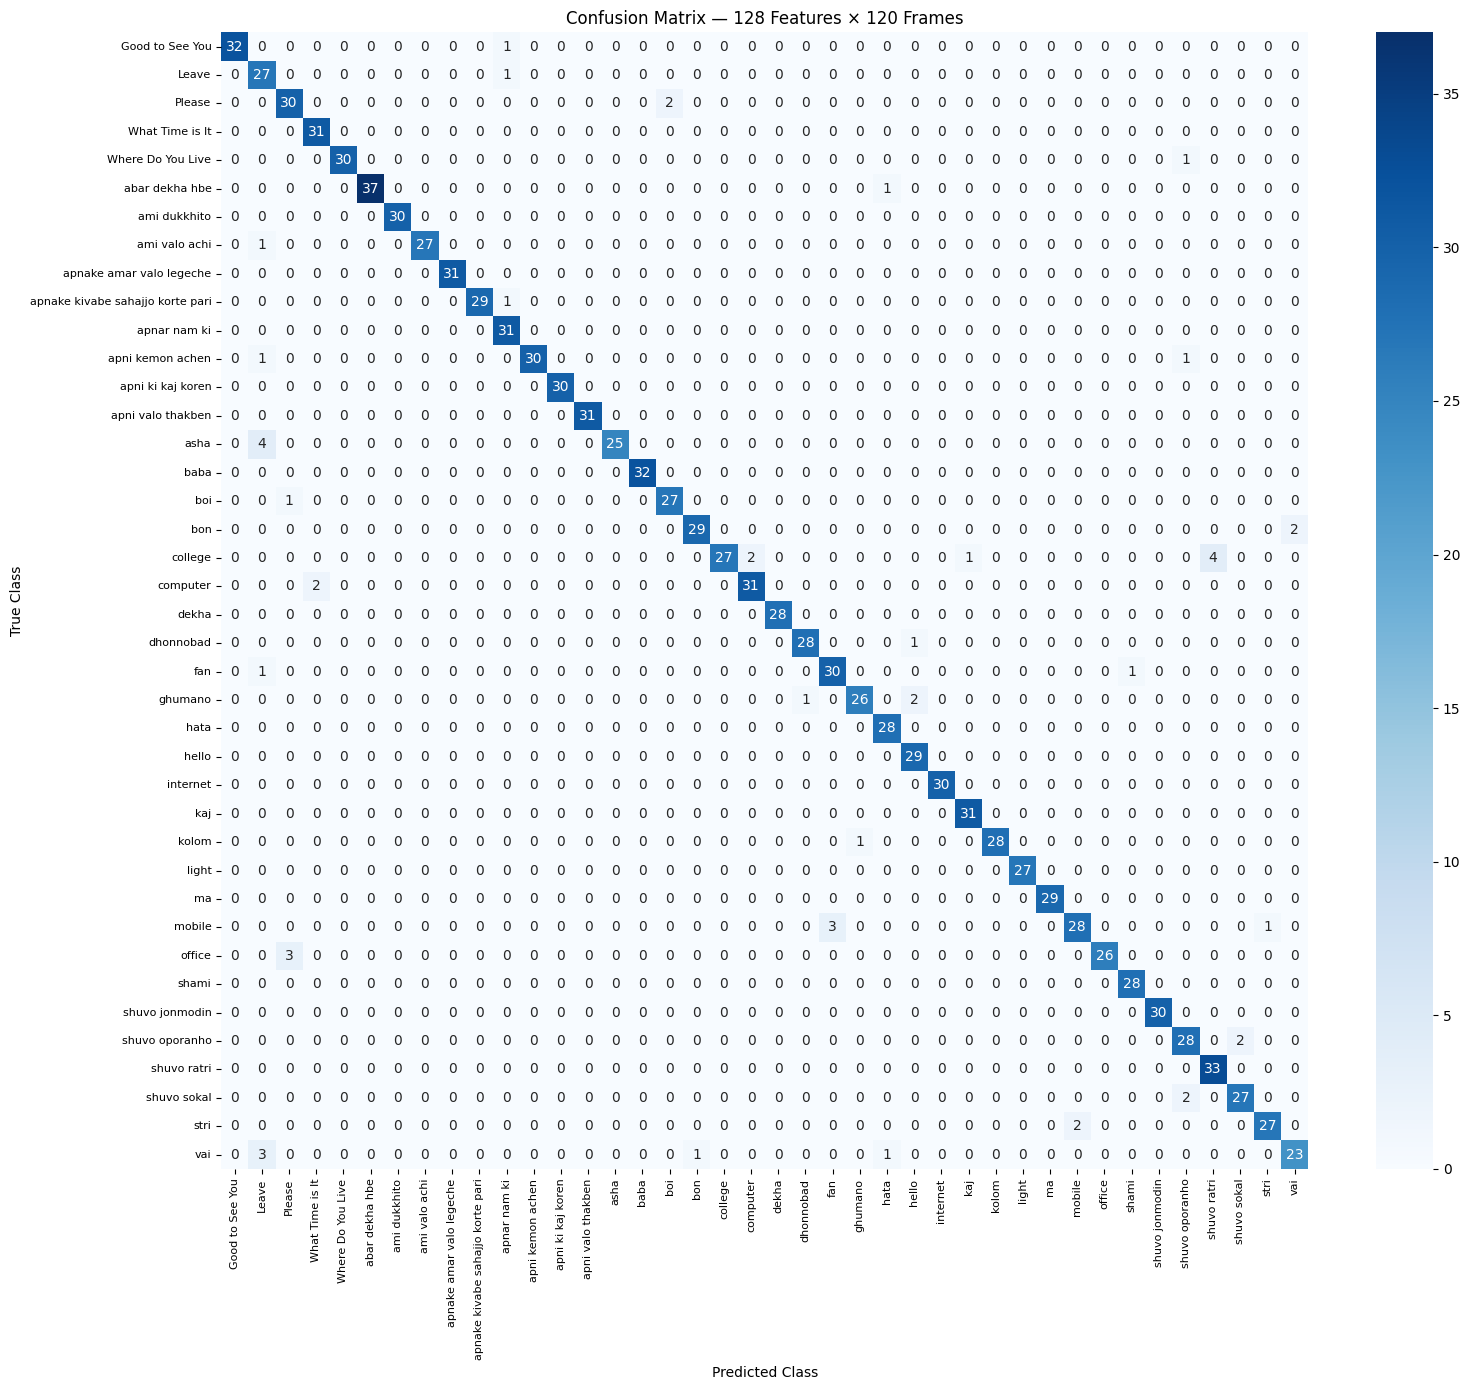

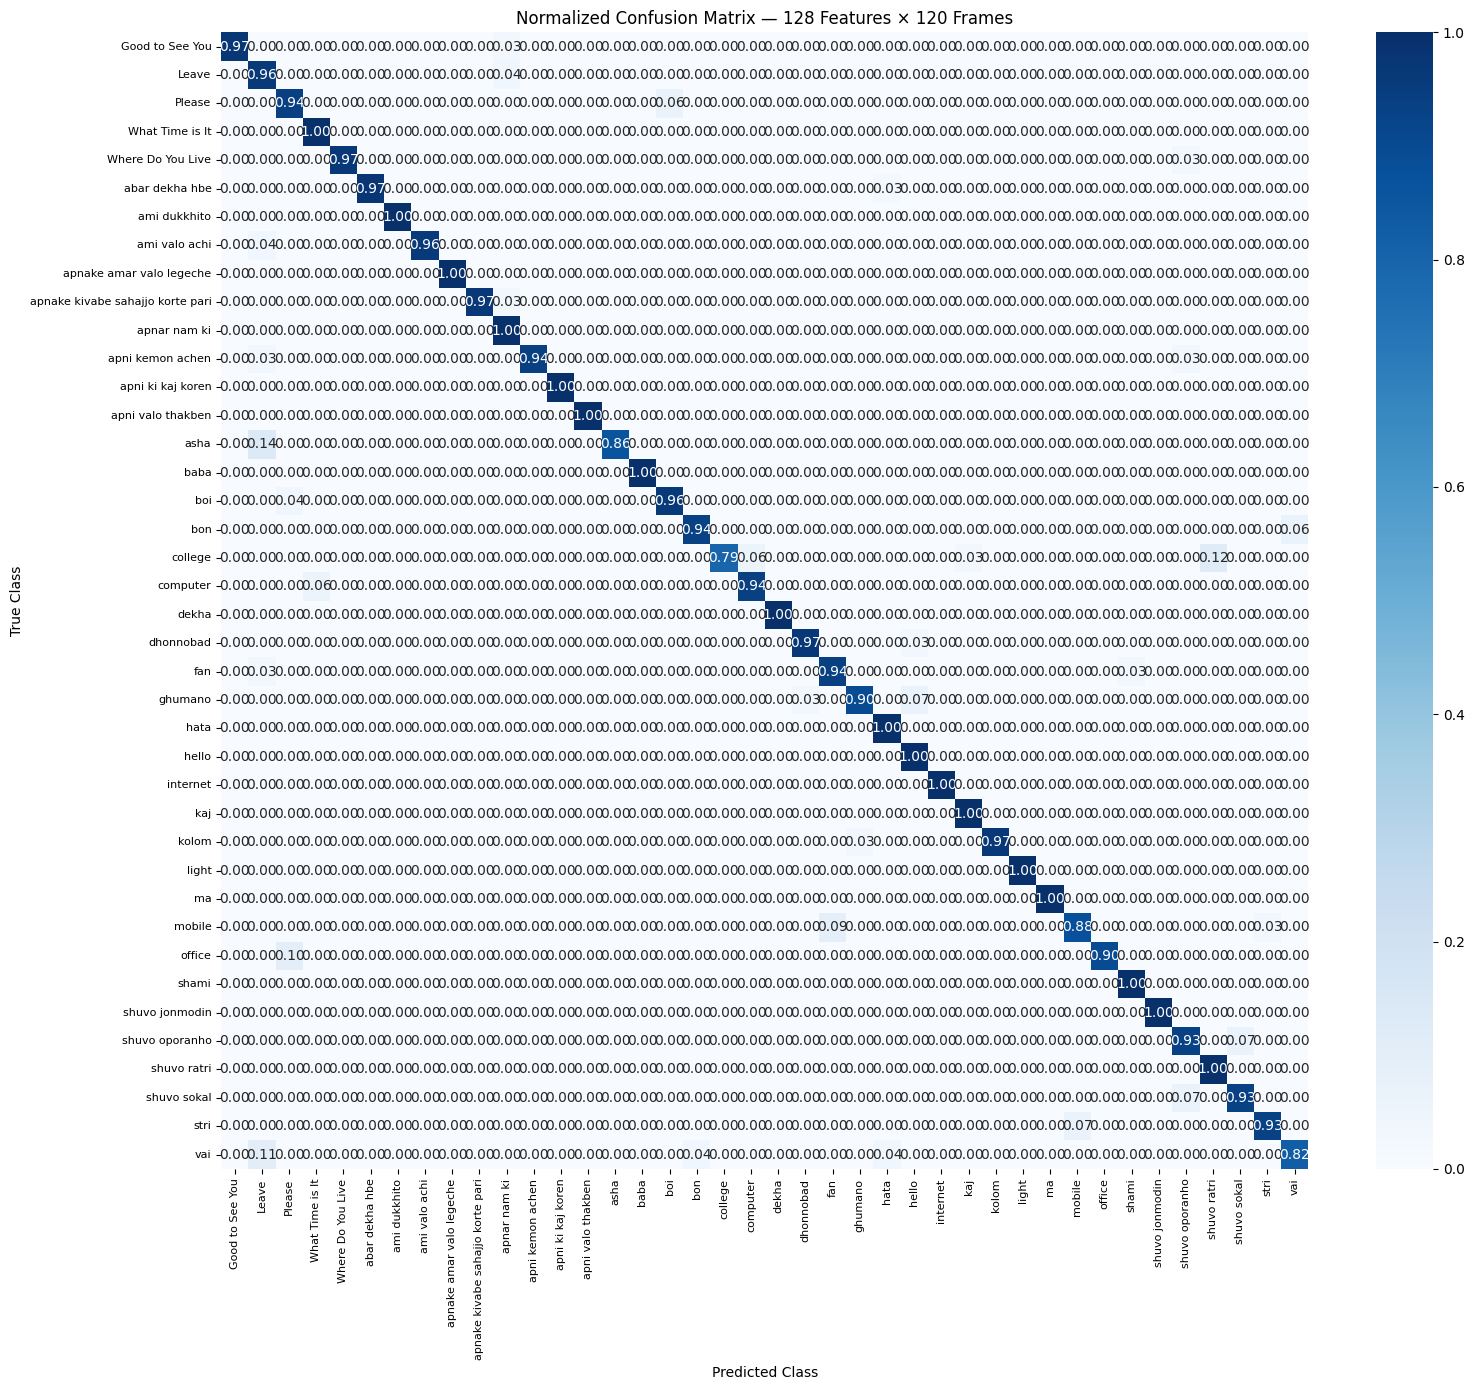


STAGE 2 FINAL SUMMARY (IN-MEMORY)

Experiment:
128 Features × 120 Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
40

Training Samples:
6179

Validation Samples:
1275

Testing Samples:
1212

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
0.226457

Test Accuracy:
0.957921

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
53

Best Validation Accuracy:
0.964706

Best Validation Loss:
0.194286

Training Time:
154.96 minutes



STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)
Test Accuracy: 0.9579
Best Validation Accuracy: 0.9647
Done.


In [4]:


# ============================================================
# ABLATION STUDY — FEATURE CONFIGURATION
# ============================================================
# Change ONLY these four switches for each ablation experiment.
#
# Feature layout (1-based):
#    Left-hand XYZ        : 1–63    -> Python indices 0:63
#    Right-hand XYZ       : 64–126  -> Python indices 63:126
#    Wrist distances     : 127–128 -> Python indices 126:128
#    Elbow distances     : 129–130 -> Python indices 128:130
#
# True  = include the block
# False = exclude the block

USE_LEFT_HAND = True
USE_RIGHT_HAND = True
USE_WRIST_DISTANCES = False
USE_ELBOW_DISTANCES = True

# Build the selected feature indices automatically.
SELECTED_FEATURE_INDICES = []
FEATURE_BLOCKS = []

if USE_LEFT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(0, 63))
    FEATURE_BLOCKS.append("left_hand")

if USE_RIGHT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(63, 126))
    FEATURE_BLOCKS.append("right_hand")

if USE_WRIST_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(126, 128))
    FEATURE_BLOCKS.append("wrist_distances")

if USE_ELBOW_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(128, 130))
    FEATURE_BLOCKS.append("elbow_distances")

if not SELECTED_FEATURE_INDICES:
    raise ValueError("At least one feature block must be enabled.")

NUM_FEATURES = len(SELECTED_FEATURE_INDICES)
EXPERIMENT_NAME = f"{NUM_FEATURES}F_" + "_".join(FEATURE_BLOCKS)

print("\n" + "=" * 70)
print("FEATURE ABLATION CONFIGURATION")
print("=" * 70)
print("Experiment:", EXPERIMENT_NAME)
print("Target frames:", TARGET_FRAMES)
print("Left hand:", USE_LEFT_HAND)
print("Right hand:", USE_RIGHT_HAND)
print("Wrist distances:", USE_WRIST_DISTANCES)
print("Elbow distances:", USE_ELBOW_DISTANCES)
print("Selected feature indices (0-based):", SELECTED_FEATURE_INDICES)
print("Number of selected features:", NUM_FEATURES)
print("=" * 70)

BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 0.0005

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. CHECK DATASET STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("CHECKING DATASET")
print("=" * 70)

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Train path not found: {TRAIN_PATH}")

if not os.path.exists(VAL_PATH):
    raise FileNotFoundError(f"Validation path not found: {VAL_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Test path not found: {TEST_PATH}")


# ============================================================
# 3. LOAD SEQUENCES WITH FEATURE ABLATION
# ============================================================

def load_and_select_sequences_from_folder(base_path):
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    sequences = []
    labels = []

    print("\nLoading:", base_path)
    print("Classes found:", len(class_names))
    print("Selected feature blocks:", ", ".join(FEATURE_BLOCKS))
    print("Selected feature count:", NUM_FEATURES)

    for class_name in class_names:
        class_path = os.path.join(base_path, class_name)

        video_names = sorted([
            d for d in os.listdir(class_path)
            if os.path.isdir(os.path.join(class_path, d))
        ])

        print(
            f"{class_name:<35} "
            f"{len(video_names):>4} videos"
        )

        for video_name in video_names:
            video_path = os.path.join(class_path, video_name)

            frames = []
            valid_video = True

            for frame_num in range(1, ORIGINAL_SEQUENCE_LENGTH + 1):
                frame_file = os.path.join(
                    video_path,
                    f"{frame_num:03d}.npy"
                )

                if not os.path.exists(frame_file):
                    print(f"WARNING: Missing frame: {frame_file}")
                    valid_video = False
                    break

                frame = np.load(frame_file)

                if frame.shape != (130,):
                    print(
                        f"WARNING: Wrong shape: {frame_file} "
                        f"-> {frame.shape}; expected (130,)"
                    )
                    valid_video = False
                    break

                selected_frame = frame[SELECTED_FEATURE_INDICES]
                frames.append(selected_frame)

            if not valid_video:
                print(
                    f"Skipping incomplete video: "
                    f"{class_name}/{video_name}"
                )
                continue

            video_stack = np.stack(frames)
            sequences.append(video_stack)
            labels.append(class_name)

    X = np.asarray(sequences, dtype=np.float32)
    y = np.asarray(labels)

    print("\nLoaded:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, class_names


# ============================================================
# 4. LOAD TRAIN / VALIDATION / TEST
# ============================================================

start_loading = time.time()

X_train, y_train, train_classes = load_and_select_sequences_from_folder(TRAIN_PATH)
X_val, y_val, val_classes = load_and_select_sequences_from_folder(VAL_PATH)
X_test, y_test, test_classes = load_and_select_sequences_from_folder(TEST_PATH)

print(
    f"\nTotal loading and slicing time: "
    f"{time.time() - start_loading:.2f} seconds"
)


# ============================================================
# 5. BASIC DATA CHECKS
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("Train classes:", len(train_classes))
print("Val classes  :", len(val_classes))
print("Test classes :", len(test_classes))

if X_train.ndim != 3:
    raise ValueError("X_train must be 3-dimensional.")

if X_train.shape[1] != TARGET_FRAMES:
    raise ValueError(
        f"Expected {TARGET_FRAMES} frames after slicing, "
        f"got {X_train.shape[1]}"
    )

if X_train.shape[2] != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} selected features, "
        f"got {X_train.shape[2]}"
    )

if len(train_classes) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} classes, "
        f"found {len(train_classes)}"
    )


# ============================================================
# 6. COMBINE CLASS NAMES
# ============================================================

actions = sorted(
    list(
        set(train_classes)
        | set(val_classes)
        | set(test_classes)
    )
)

print("\nFinal classes:", len(actions))

if len(actions) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} total classes, "
        f"found {len(actions)}"
    )

print("\nClass list:")
for i, action in enumerate(actions):
    print(f"{i:02d}: {action}")


# ============================================================
# 7. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()
label_encoder.fit(actions)

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("\nEncoded labels:")
print("Train:", y_train_encoded.shape)
print("Val  :", y_val_encoded.shape)
print("Test :", y_test_encoded.shape)


# ============================================================
# 8. CLASS DISTRIBUTION PRINT AND PLOT
# ============================================================

def print_and_plot_class_distribution(labels, split_name):
    counts = Counter(labels)
    print(f"\n--- {split_name.upper()} Class Distribution ---")
    for class_name in actions:
        print(f"{class_name}: {counts.get(class_name, 0)} videos")

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(actions)), [counts.get(a, 0) for a in actions])
    plt.xticks(range(len(actions)), actions, rotation=90)
    plt.xlabel("Class")
    plt.ylabel("Number of Videos")
    plt.title(f"{split_name.capitalize()} Class Distribution ({TARGET_FRAMES} Frames)")
    plt.tight_layout()
    plt.show()

print_and_plot_class_distribution(y_train, "train")
print_and_plot_class_distribution(y_val, "validation")
print_and_plot_class_distribution(y_test, "test")


# ============================================================
# 9. STANDARDIZATION
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZATION")
print("=" * 70)

scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, NUM_FEATURES)
X_val_flat = X_val.reshape(-1, NUM_FEATURES)
X_test_flat = X_test.reshape(-1, NUM_FEATURES)

print("Fitting scaler on training data...")
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)

print("Transforming validation data...")
X_val_scaled = scaler.transform(X_val_flat).reshape(X_val.shape)

print("Transforming test data...")
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

print("Scaling completed.")


# ============================================================
# 10. ONE-HOT ENCODING
# ============================================================

y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=len(actions))
y_val_cat = tf.keras.utils.to_categorical(y_val_encoded, num_classes=len(actions))
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(actions))


# ============================================================
# 11. BUILD MODEL
# ============================================================

print("\n" + "=" * 70)
print("BUILDING MODEL")
print("=" * 70)

inp = Input(shape=(TARGET_FRAMES, NUM_FEATURES))

x = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inp)
x = BatchNormalization()(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

query = Dense(64)(x)
value = Dense(64)(x)

x = Attention()([query, value])
x = GlobalAveragePooling1D()(x)

x = Dense(128, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

out = Dense(len(actions), activation="softmax")(x)

model = Model(inputs=inp, outputs=out)


# ============================================================
# 12. COMPILE & SUMMARY
# ============================================================

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 13. CALLBACKS (In-Memory Weights Tracking)
# ============================================================

class InMemoryModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_weights = None
        self.best_val_accuracy = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc > self.best_val_accuracy:
            self.best_val_accuracy = val_acc
            self.best_weights = self.model.get_weights()
            print(f"\n[Epoch {epoch + 1}] Validation accuracy improved to {val_acc:.4f}. Weights captured in memory.")

checkpoint_callback = InMemoryModelCheckpoint()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 14. TRAINING
# ============================================================

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

training_start = time.time()

history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        checkpoint_callback,
        reduce_lr
    ],
    verbose=1
)

training_time = time.time() - training_start

print(f"\nTraining completed in {training_time / 60:.2f} minutes")

if checkpoint_callback.best_weights is not None:
    model.set_weights(checkpoint_callback.best_weights)
    print("Loaded best weights captured during training.")


# ============================================================
# 15. TRAINING ACCURACY & LOSS PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Training and Validation Accuracy ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 16. TEST EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("TEST EVALUATION")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test_cat,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.6f}")
print(f"Test Accuracy : {test_accuracy:.6f}")


# ============================================================
# 17. PREDICTIONS & METRICS
# ============================================================

y_prob = model.predict(X_test_scaled, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

report_text = classification_report(
    y_test_encoded,
    y_pred,
    target_names=actions,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report_text)


# ============================================================
# 19. CONFUSION MATRIX PLOTS
# ============================================================

cm = confusion_matrix(
    y_test_encoded,
    y_pred,
    labels=range(len(actions))
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

cm_normalized = (
    cm.astype(np.float64)
    / cm.sum(axis=1, keepdims=True)
)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Normalized Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 20. FINAL SUMMARY DISPLAY
# ============================================================

summary_text = f"""
============================================================
STAGE 2 FINAL SUMMARY (IN-MEMORY)
============================================================

Experiment:
{NUM_FEATURES} Features × {TARGET_FRAMES} Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
{len(actions)}

Training Samples:
{len(X_train)}

Validation Samples:
{len(X_val)}

Testing Samples:
{len(X_test)}

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
{test_loss:.6f}

Test Accuracy:
{test_accuracy:.6f}

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
{best_epoch}

Best Validation Accuracy:
{best_val_accuracy:.6f}

Best Validation Loss:
{best_val_loss:.6f}

Training Time:
{training_time / 60:.2f} minutes

============================================================
"""

print(summary_text)

print("\n" + "=" * 70)
print("STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)")
print("=" * 70)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print("Done.")

wrist only + elbow only


FEATURE ABLATION CONFIGURATION
Experiment: 4F_wrist_distances_elbow_distances
Target frames: 120
Left hand: False
Right hand: False
Wrist distances: True
Elbow distances: True
Selected feature indices (0-based): [126, 127, 128, 129]
Number of selected features: 4

CHECKING DATASET
Train path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\train_csv
Validation path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\validation_csv
Test path: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\test_csv

Loading: D:\aaa EAAI Major Revision\dynamic\dynamic_dataset\csv_dataset\train_csv
Classes found: 40
Selected feature blocks: wrist_distances, elbow_distances
Selected feature count: 4
Good to See You                      174 videos
Leave                                150 videos
Please                               159 videos
What Time is It                      170 videos
Where Do You Live                    175 videos
abar dekha hbe               

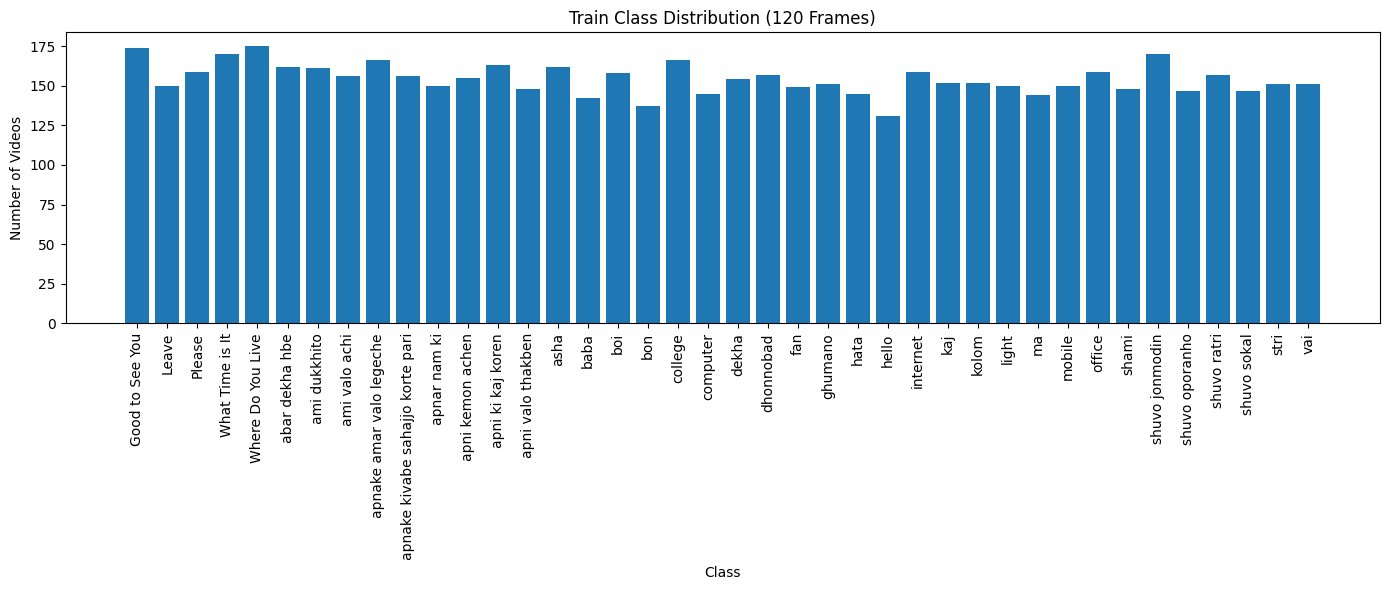


--- VALIDATION Class Distribution ---
Good to See You: 27 videos
Leave: 35 videos
Please: 29 videos
What Time is It: 28 videos
Where Do You Live: 38 videos
abar dekha hbe: 31 videos
ami dukkhito: 31 videos
ami valo achi: 28 videos
apnake amar valo legeche: 29 videos
apnake kivabe sahajjo korte pari: 31 videos
apnar nam ki: 32 videos
apni kemon achen: 35 videos
apni ki kaj koren: 33 videos
apni valo thakben: 33 videos
asha: 34 videos
baba: 30 videos
boi: 33 videos
bon: 31 videos
college: 31 videos
computer: 37 videos
dekha: 33 videos
dhonnobad: 27 videos
fan: 32 videos
ghumano: 31 videos
hata: 30 videos
hello: 30 videos
internet: 34 videos
kaj: 29 videos
kolom: 37 videos
light: 41 videos
ma: 31 videos
mobile: 29 videos
office: 31 videos
shami: 30 videos
shuvo jonmodin: 34 videos
shuvo oporanho: 30 videos
shuvo ratri: 34 videos
shuvo sokal: 38 videos
stri: 29 videos
vai: 29 videos


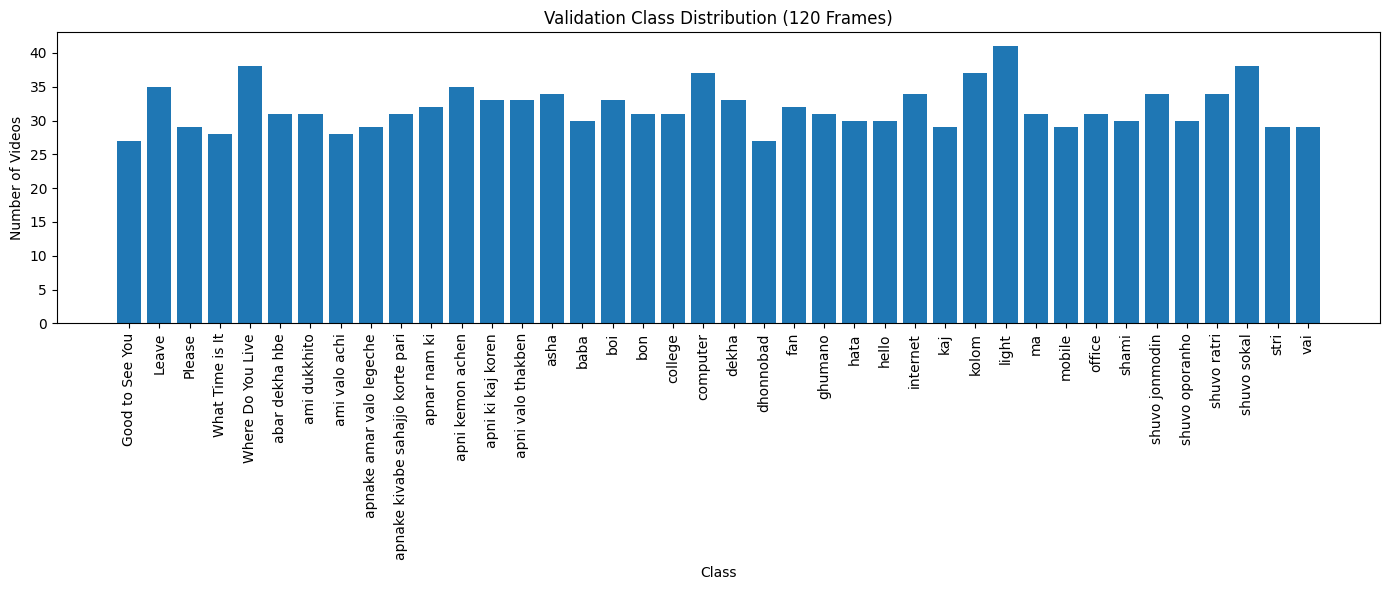


--- TEST Class Distribution ---
Good to See You: 33 videos
Leave: 28 videos
Please: 32 videos
What Time is It: 31 videos
Where Do You Live: 31 videos
abar dekha hbe: 38 videos
ami dukkhito: 30 videos
ami valo achi: 28 videos
apnake amar valo legeche: 31 videos
apnake kivabe sahajjo korte pari: 30 videos
apnar nam ki: 31 videos
apni kemon achen: 32 videos
apni ki kaj koren: 30 videos
apni valo thakben: 31 videos
asha: 29 videos
baba: 32 videos
boi: 28 videos
bon: 31 videos
college: 34 videos
computer: 33 videos
dekha: 28 videos
dhonnobad: 29 videos
fan: 32 videos
ghumano: 29 videos
hata: 28 videos
hello: 29 videos
internet: 30 videos
kaj: 31 videos
kolom: 29 videos
light: 27 videos
ma: 29 videos
mobile: 32 videos
office: 29 videos
shami: 28 videos
shuvo jonmodin: 30 videos
shuvo oporanho: 30 videos
shuvo ratri: 33 videos
shuvo sokal: 29 videos
stri: 29 videos
vai: 28 videos


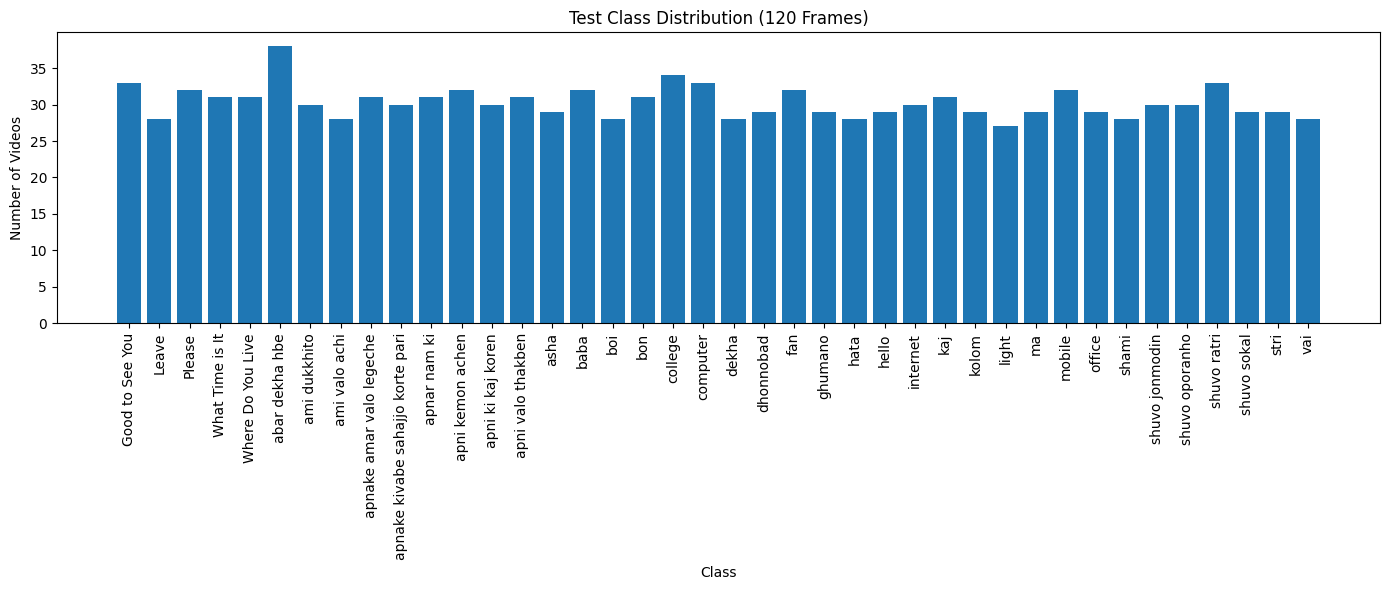


STANDARDIZATION
Fitting scaler on training data...
Transforming validation data...
Transforming test data...
Scaling completed.

BUILDING MODEL


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 120, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 120, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 120, 256)  │    197,632 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 256)  │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 120, 256)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 120, 128)  │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 128)  │        512 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 120, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 120, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 120, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 120, 64)   │          0 │ dense[0][0],      │
│ (Attention)         │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 40)        │      2,600 │ dropout_3[0][0] 

 Total params: 401,064 (1.53 MB)

 Trainable params: 399,784 (1.53 MB)

 Non-trainable params: 1,280 (5.00 KB)


TRAINING
Epoch 1/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0428 - loss: 4.2030
[Epoch 1] Validation accuracy improved to 0.0557. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.0515 - loss: 4.0148 - val_accuracy: 0.0557 - val_loss: 3.5722 - learning_rate: 5.0000e-04
Epoch 2/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0783 - loss: 3.5405
[Epoch 2] Validation accuracy improved to 0.1098. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.0893 - loss: 3.4440 - val_accuracy: 0.1098 - val_loss: 3.0576 - learning_rate: 5.0000e-04
Epoch 3/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1085 - loss: 3.1634
[Epoch 3] Validation accuracy improved to 0.1569. Weights captured in memory.
97/97 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.1173 - loss: 3.1201 - val_accuracy: 0.1569 - val_loss: 2.7403 - learning_rate: 5.0000e-04
Epoch 4/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1385 - l

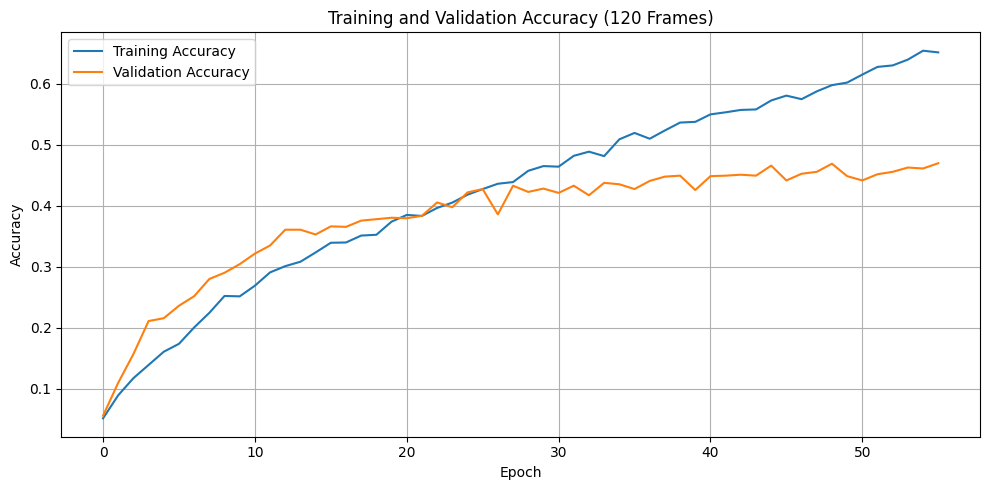

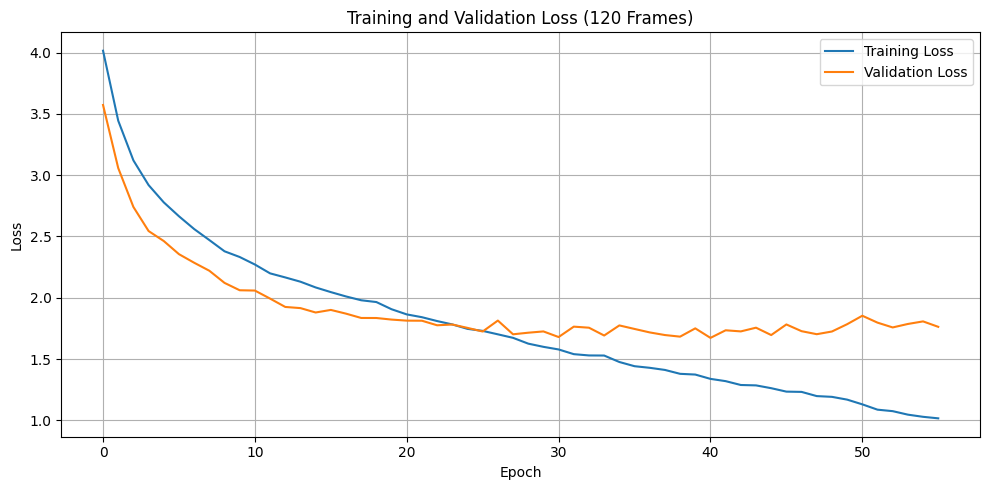


TEST EVALUATION
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.4043 - loss: 2.2801

Test Loss     : 2.280086
Test Accuracy : 0.404290
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step

CLASSIFICATION REPORT
                                  precision    recall  f1-score   support

                 Good to See You       0.79      0.82      0.81        33
                           Leave       0.13      0.25      0.17        28
                          Please       0.69      0.56      0.62        32
                 What Time is It       0.46      0.42      0.44        31
               Where Do You Live       0.96      0.74      0.84        31
                  abar dekha hbe       0.68      0.39      0.50        38
                    ami dukkhito       0.27      0.40      0.32        30
                   ami valo achi       0.38      0.71      0.49        28
        apnake amar valo legeche       0.32      0.19      0.24        31
apnake kivabe sahajjo korte pari       0.56      0.7

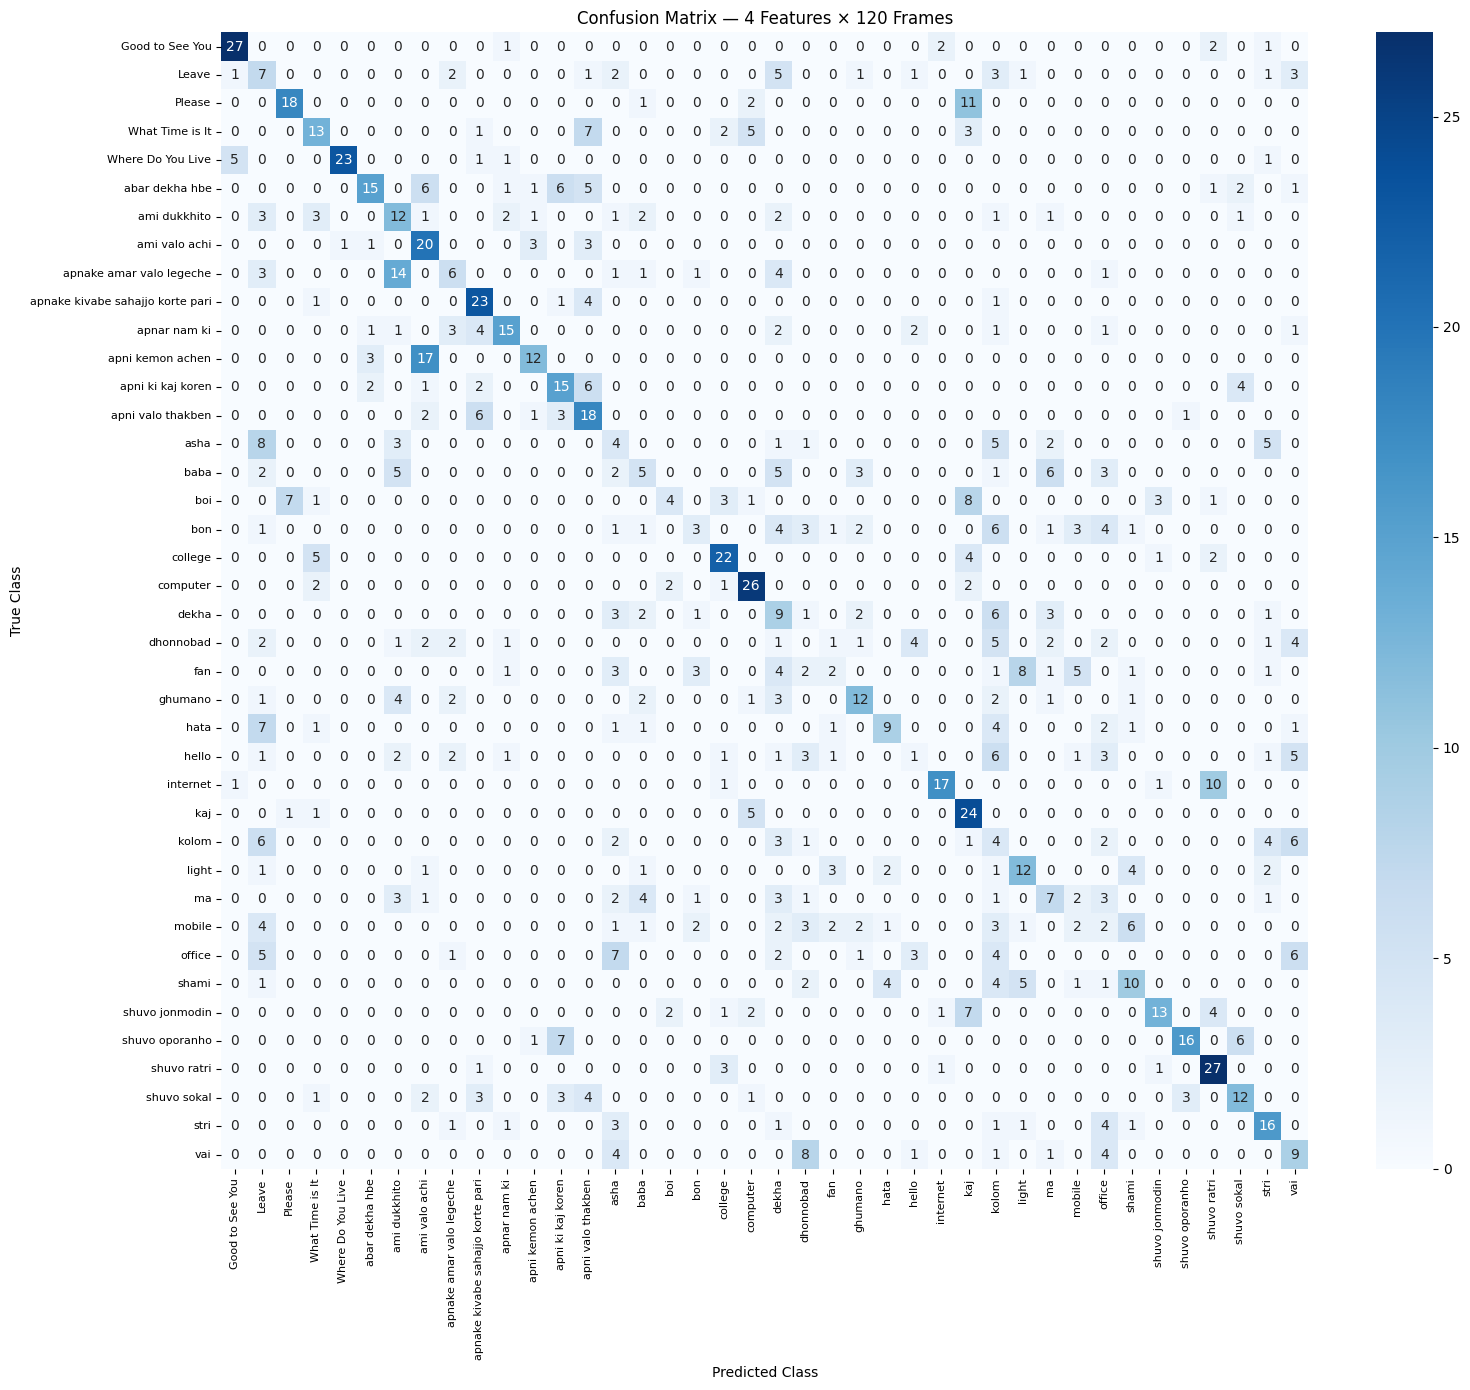

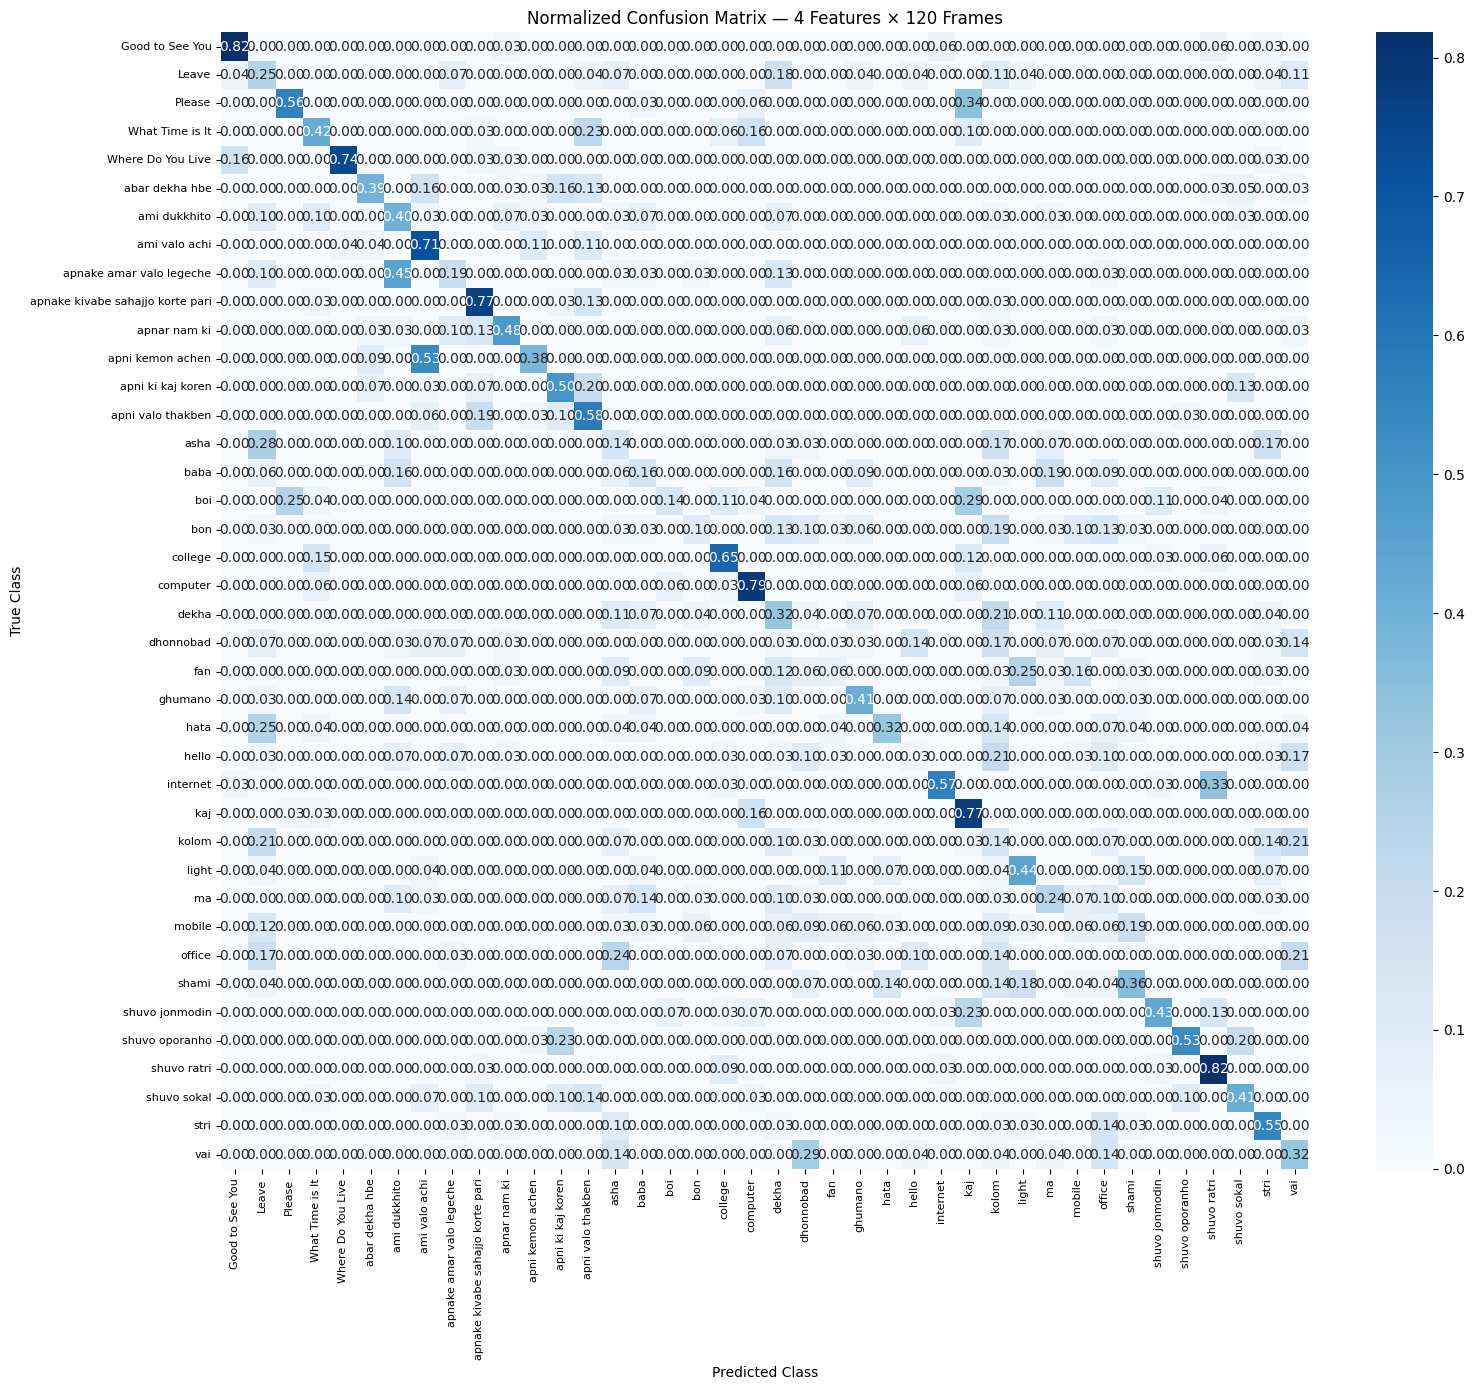


STAGE 2 FINAL SUMMARY (IN-MEMORY)

Experiment:
4 Features × 120 Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
40

Training Samples:
6179

Validation Samples:
1275

Testing Samples:
1212

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
2.280086

Test Accuracy:
0.404290

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
56

Best Validation Accuracy:
0.469804

Best Validation Loss:
1.672462

Training Time:
187.64 minutes



STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)
Test Accuracy: 0.4043
Best Validation Accuracy: 0.4698
Done.


In [2]:
# ============================================================
# STAGE 2 — FEATURE ABLATION (IN-MEMORY + PLOTS SHOWN)
# Student-Independent Sign Language Recognition
# 120 Frames × Configurable Feature Subset
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Bidirectional,
    Attention,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# 1. SETTINGS
# ============================================================

BASE_DIR = r"D:\aaa EAAI Major Revision\dynamic\dynamic_dataset"
DATA_DIR = os.path.join(BASE_DIR, "csv_dataset")

TRAIN_PATH = os.path.join(DATA_DIR, "train_csv")
VAL_PATH = os.path.join(DATA_DIR, "validation_csv")
TEST_PATH = os.path.join(DATA_DIR, "test_csv")

ORIGINAL_SEQUENCE_LENGTH = 120
TARGET_FRAMES = 120
EXPECTED_CLASSES = 40

# ============================================================
# ABLATION STUDY — FEATURE CONFIGURATION
# ============================================================
# Change ONLY these four switches for each ablation experiment.
#
# Feature layout (1-based):
#    Left-hand XYZ        : 1–63    -> Python indices 0:63
#    Right-hand XYZ       : 64–126  -> Python indices 63:126
#    Wrist distances     : 127–128 -> Python indices 126:128
#    Elbow distances     : 129–130 -> Python indices 128:130
#
# True  = include the block
# False = exclude the block

USE_LEFT_HAND = False
USE_RIGHT_HAND = False
USE_WRIST_DISTANCES = True
USE_ELBOW_DISTANCES = True

# Build the selected feature indices automatically.
SELECTED_FEATURE_INDICES = []
FEATURE_BLOCKS = []

if USE_LEFT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(0, 63))
    FEATURE_BLOCKS.append("left_hand")

if USE_RIGHT_HAND:
    SELECTED_FEATURE_INDICES.extend(range(63, 126))
    FEATURE_BLOCKS.append("right_hand")

if USE_WRIST_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(126, 128))
    FEATURE_BLOCKS.append("wrist_distances")

if USE_ELBOW_DISTANCES:
    SELECTED_FEATURE_INDICES.extend(range(128, 130))
    FEATURE_BLOCKS.append("elbow_distances")

if not SELECTED_FEATURE_INDICES:
    raise ValueError("At least one feature block must be enabled.")

NUM_FEATURES = len(SELECTED_FEATURE_INDICES)
EXPERIMENT_NAME = f"{NUM_FEATURES}F_" + "_".join(FEATURE_BLOCKS)

print("\n" + "=" * 70)
print("FEATURE ABLATION CONFIGURATION")
print("=" * 70)
print("Experiment:", EXPERIMENT_NAME)
print("Target frames:", TARGET_FRAMES)
print("Left hand:", USE_LEFT_HAND)
print("Right hand:", USE_RIGHT_HAND)
print("Wrist distances:", USE_WRIST_DISTANCES)
print("Elbow distances:", USE_ELBOW_DISTANCES)
print("Selected feature indices (0-based):", SELECTED_FEATURE_INDICES)
print("Number of selected features:", NUM_FEATURES)
print("=" * 70)

BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 0.0005

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. CHECK DATASET STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("CHECKING DATASET")
print("=" * 70)

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Train path not found: {TRAIN_PATH}")

if not os.path.exists(VAL_PATH):
    raise FileNotFoundError(f"Validation path not found: {VAL_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Test path not found: {TEST_PATH}")


# ============================================================
# 3. LOAD SEQUENCES WITH FEATURE ABLATION
# ============================================================

def load_and_select_sequences_from_folder(base_path):
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    sequences = []
    labels = []

    print("\nLoading:", base_path)
    print("Classes found:", len(class_names))
    print("Selected feature blocks:", ", ".join(FEATURE_BLOCKS))
    print("Selected feature count:", NUM_FEATURES)

    for class_name in class_names:
        class_path = os.path.join(base_path, class_name)

        video_names = sorted([
            d for d in os.listdir(class_path)
            if os.path.isdir(os.path.join(class_path, d))
        ])

        print(
            f"{class_name:<35} "
            f"{len(video_names):>4} videos"
        )

        for video_name in video_names:
            video_path = os.path.join(class_path, video_name)

            frames = []
            valid_video = True

            for frame_num in range(1, ORIGINAL_SEQUENCE_LENGTH + 1):
                frame_file = os.path.join(
                    video_path,
                    f"{frame_num:03d}.npy"
                )

                if not os.path.exists(frame_file):
                    print(f"WARNING: Missing frame: {frame_file}")
                    valid_video = False
                    break

                frame = np.load(frame_file)

                if frame.shape != (130,):
                    print(
                        f"WARNING: Wrong shape: {frame_file} "
                        f"-> {frame.shape}; expected (130,)"
                    )
                    valid_video = False
                    break

                selected_frame = frame[SELECTED_FEATURE_INDICES]
                frames.append(selected_frame)

            if not valid_video:
                print(
                    f"Skipping incomplete video: "
                    f"{class_name}/{video_name}"
                )
                continue

            video_stack = np.stack(frames)
            sequences.append(video_stack)
            labels.append(class_name)

    X = np.asarray(sequences, dtype=np.float32)
    y = np.asarray(labels)

    print("\nLoaded:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, class_names


# ============================================================
# 4. LOAD TRAIN / VALIDATION / TEST
# ============================================================

start_loading = time.time()

X_train, y_train, train_classes = load_and_select_sequences_from_folder(TRAIN_PATH)
X_val, y_val, val_classes = load_and_select_sequences_from_folder(VAL_PATH)
X_test, y_test, test_classes = load_and_select_sequences_from_folder(TEST_PATH)

print(
    f"\nTotal loading and slicing time: "
    f"{time.time() - start_loading:.2f} seconds"
)


# ============================================================
# 5. BASIC DATA CHECKS
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("Train classes:", len(train_classes))
print("Val classes  :", len(val_classes))
print("Test classes :", len(test_classes))

if X_train.ndim != 3:
    raise ValueError("X_train must be 3-dimensional.")

if X_train.shape[1] != TARGET_FRAMES:
    raise ValueError(
        f"Expected {TARGET_FRAMES} frames after slicing, "
        f"got {X_train.shape[1]}"
    )

if X_train.shape[2] != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} selected features, "
        f"got {X_train.shape[2]}"
    )

if len(train_classes) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} classes, "
        f"found {len(train_classes)}"
    )


# ============================================================
# 6. COMBINE CLASS NAMES
# ============================================================

actions = sorted(
    list(
        set(train_classes)
        | set(val_classes)
        | set(test_classes)
    )
)

print("\nFinal classes:", len(actions))

if len(actions) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} total classes, "
        f"found {len(actions)}"
    )

print("\nClass list:")
for i, action in enumerate(actions):
    print(f"{i:02d}: {action}")


# ============================================================
# 7. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()
label_encoder.fit(actions)

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("\nEncoded labels:")
print("Train:", y_train_encoded.shape)
print("Val  :", y_val_encoded.shape)
print("Test :", y_test_encoded.shape)


# ============================================================
# 8. CLASS DISTRIBUTION PRINT AND PLOT
# ============================================================

def print_and_plot_class_distribution(labels, split_name):
    counts = Counter(labels)
    print(f"\n--- {split_name.upper()} Class Distribution ---")
    for class_name in actions:
        print(f"{class_name}: {counts.get(class_name, 0)} videos")

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(actions)), [counts.get(a, 0) for a in actions])
    plt.xticks(range(len(actions)), actions, rotation=90)
    plt.xlabel("Class")
    plt.ylabel("Number of Videos")
    plt.title(f"{split_name.capitalize()} Class Distribution ({TARGET_FRAMES} Frames)")
    plt.tight_layout()
    plt.show()

print_and_plot_class_distribution(y_train, "train")
print_and_plot_class_distribution(y_val, "validation")
print_and_plot_class_distribution(y_test, "test")


# ============================================================
# 9. STANDARDIZATION
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZATION")
print("=" * 70)

scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, NUM_FEATURES)
X_val_flat = X_val.reshape(-1, NUM_FEATURES)
X_test_flat = X_test.reshape(-1, NUM_FEATURES)

print("Fitting scaler on training data...")
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)

print("Transforming validation data...")
X_val_scaled = scaler.transform(X_val_flat).reshape(X_val.shape)

print("Transforming test data...")
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

print("Scaling completed.")


# ============================================================
# 10. ONE-HOT ENCODING
# ============================================================

y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=len(actions))
y_val_cat = tf.keras.utils.to_categorical(y_val_encoded, num_classes=len(actions))
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(actions))


# ============================================================
# 11. BUILD MODEL
# ============================================================

print("\n" + "=" * 70)
print("BUILDING MODEL")
print("=" * 70)

inp = Input(shape=(TARGET_FRAMES, NUM_FEATURES))

x = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inp)
x = BatchNormalization()(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

query = Dense(64)(x)
value = Dense(64)(x)

x = Attention()([query, value])
x = GlobalAveragePooling1D()(x)

x = Dense(128, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu", kernel_regularizer=l2(1e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

out = Dense(len(actions), activation="softmax")(x)

model = Model(inputs=inp, outputs=out)


# ============================================================
# 12. COMPILE & SUMMARY
# ============================================================

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 13. CALLBACKS (In-Memory Weights Tracking)
# ============================================================

class InMemoryModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_weights = None
        self.best_val_accuracy = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc > self.best_val_accuracy:
            self.best_val_accuracy = val_acc
            self.best_weights = self.model.get_weights()
            print(f"\n[Epoch {epoch + 1}] Validation accuracy improved to {val_acc:.4f}. Weights captured in memory.")

checkpoint_callback = InMemoryModelCheckpoint()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 14. TRAINING
# ============================================================

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

training_start = time.time()

history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        checkpoint_callback,
        reduce_lr
    ],
    verbose=1
)

training_time = time.time() - training_start

print(f"\nTraining completed in {training_time / 60:.2f} minutes")

if checkpoint_callback.best_weights is not None:
    model.set_weights(checkpoint_callback.best_weights)
    print("Loaded best weights captured during training.")


# ============================================================
# 15. TRAINING ACCURACY & LOSS PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Training and Validation Accuracy ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss ({TARGET_FRAMES} Frames)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 16. TEST EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("TEST EVALUATION")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test_cat,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.6f}")
print(f"Test Accuracy : {test_accuracy:.6f}")


# ============================================================
# 17. PREDICTIONS & METRICS
# ============================================================

y_prob = model.predict(X_test_scaled, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

report_text = classification_report(
    y_test_encoded,
    y_pred,
    target_names=actions,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report_text)


# ============================================================
# 19. CONFUSION MATRIX PLOTS
# ============================================================

cm = confusion_matrix(
    y_test_encoded,
    y_pred,
    labels=range(len(actions))
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

cm_normalized = (
    cm.astype(np.float64)
    / cm.sum(axis=1, keepdims=True)
)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=actions,
    yticklabels=actions,
    cbar=True
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Normalized Confusion Matrix — {NUM_FEATURES} Features × {TARGET_FRAMES} Frames")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 20. FINAL SUMMARY DISPLAY
# ============================================================

summary_text = f"""
============================================================
STAGE 2 FINAL SUMMARY (IN-MEMORY)
============================================================

Experiment:
{NUM_FEATURES} Features × {TARGET_FRAMES} Frames (Extracted from 120)

Dataset:
Student-Independent

Number of Classes:
{len(actions)}

Training Samples:
{len(X_train)}

Validation Samples:
{len(X_val)}

Testing Samples:
{len(X_test)}

------------------------------------------------------------
RESULTS
------------------------------------------------------------

Test Loss:
{test_loss:.6f}

Test Accuracy:
{test_accuracy:.6f}

------------------------------------------------------------
TRAINING
------------------------------------------------------------

Best Epoch:
{best_epoch}

Best Validation Accuracy:
{best_val_accuracy:.6f}

Best Validation Loss:
{best_val_loss:.6f}

Training Time:
{training_time / 60:.2f} minutes

============================================================
"""

print(summary_text)

print("\n" + "=" * 70)
print("STAGE 2 COMPLETED (PLOTS RENDERED, NO FILES SAVED)")
print("=" * 70)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print("Done.")